# CastMe SISA unlearning

## 1. Introduction

### 1.1 Method and Personal-Data Context

SISA means **Sharded, Isolated, Sliced and Aggregated**. It structures training before deletion requests occur: independent shard models learn ordered slices, and their probabilities are averaged. A deletion request then replays only affected shards from the checkpoint before their earliest affected slice.

The existing monolithic Original Model cannot be converted into SISA after training. This notebook therefore trains a separate Original SISA ensemble using the same CastMe MLP architecture and master seed 42, without loading Notebook 01 model weights into any shard.

### 1.2 Unlearning Objective

For each saved Notebook 02 deletion scenario, affected SISA shards exclude all forget records and replay only the required slices. Unaffected final shard checkpoints are reused. This is structurally different from post-hoc retain-set fine-tuning and gradient ascent.

### 1.3 Two-Axis Evaluation

**Axis 1 — retained-data utility** compares post-deletion SISA with the Monolithic full-retraining external reference on identical retained-test rows using PR-AUC, balanced accuracy, BCE, F1 and AUROC.

**Axis 2 — CastMe Forget Quality** compares Classifier Truth Ratio distributions on identical forget rows. Cross-method and method-matched KS results are reported separately; neither is combined into one score. Behavioural similarity is not proof of complete deletion.

## 2. Imports and Setup

### 2.1 Imports

In [1]:
from __future__ import annotations

import copy
import hashlib
import json
import platform
import random
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import Markdown, display
from scipy.stats import ks_2samp
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, log_loss,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

### 2.2 Reproducibility

Seed 42 controls assignment and training. Each shard uses a deterministic derived seed so initialization is reproducible but independent. Each replay uses the same shard seed and fixed protocol.

In [2]:
# Fix every random source before assignment or model initialization.
# Derived shard seeds remain reproducible while producing independent weights.
MASTER_SEED = 42
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MASTER_SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: mps


### 2.3 Configuration

One fixed configuration is used for every shard, slice and scenario. Each cumulative stage trains for two epochs with AdamW. There is no scenario-specific tuning, multi-seed analysis, hyperparameter search or threshold retuning.

In [3]:
# Apply one approved training protocol to every shard, slice and request.
# Keep aggregation and cumulative slicing explicit for artifact provenance.
SISA_CONFIG = {
    "master_seed": MASTER_SEED,
    "number_of_shards": 5,
    "number_of_slices": 5,
    "epochs_per_slice": 2,
    "batch_size": 64,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "optimizer": "AdamW",
    "aggregation": "mean_predicted_probability",
    "slice_protocol": "cumulative_slices_1_through_j",
}
BOOTSTRAP_RESAMPLES = 1_000
BOOTSTRAP_SEED = 2025
SHARD_NUMBERS = list(range(1, SISA_CONFIG["number_of_shards"] + 1))
SLICE_NUMBERS = list(range(1, SISA_CONFIG["number_of_slices"] + 1))

### 2.4 File Paths

Paths are centralised and displayed relative to the project code root. SISA directories are created before training; all upstream CastMe artifacts remain read-only.

In [4]:
# Resolve paths from either the repository root or the code directory.
def locate_code_root(start_path: Path) -> Path:
    "Return the project code directory containing the cleaned CastMe CSV."
    for candidate in [start_path, *start_path.parents]:
        direct = candidate / "data/processed/castme/castme_auditions_clean.csv"
        nested = candidate / "code/data/processed/castme/castme_auditions_clean.csv"
        if direct.is_file():
            return candidate
        if nested.is_file():
            return candidate / "code"
    raise FileNotFoundError("Could not locate the cleaned CastMe CSV.")


CODE_ROOT = locate_code_root(Path.cwd().resolve())
DATA_PATH = CODE_ROOT / "data/processed/castme/castme_auditions_clean.csv"
BASELINE_MODEL_PATH = CODE_ROOT / "models/castme/castme_baseline_mlp.pt"
BASELINE_PREPROCESSOR_PATH = CODE_ROOT / "models/castme/castme_preprocessor.joblib"
BASELINE_MANIFEST_PATH = CODE_ROOT / "results/CastMe/configuration/baseline_manifest.json"
FULL_MODEL_ROOT = CODE_ROOT / "models/castme/full_retraining"
FULL_RESULTS_ROOT = CODE_ROOT / "results/CastMe/full_retraining"
MODEL_ROOT = CODE_ROOT / "models/castme/sisa"
RESULTS_ROOT = CODE_ROOT / "results/CastMe/sisa"
NOTEBOOK_PATHS = [CODE_ROOT / f"notebooks/CastMe/0{i}_{name}.ipynb" for i, name in [
    (1, "castme_baseline"), (2, "castme_forget_sets_and_full_retraining"),
    (3, "castme_retain_set_finetuning"), (4, "castme_gradient_ascent"),
]]

In [5]:
# Create every SISA output directory before training begins.
# Keep operational, post-deletion and evaluation-only model families separate.
OUTPUT_DIRS = {
    name: RESULTS_ROOT / name
    for name in ["configuration", "assignments", "histories", "metrics", "tables", "figures"]
}
ORIGINAL_MODEL_ROOT = MODEL_ROOT / "original"
POST_DELETION_MODEL_ROOT = MODEL_ROOT / "post_deletion"
METHOD_MATCHED_MODEL_ROOT = MODEL_ROOT / "method_matched_reference"
for directory in [*OUTPUT_DIRS.values(), ORIGINAL_MODEL_ROOT, POST_DELETION_MODEL_ROOT, METHOD_MATCHED_MODEL_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

display(pd.DataFrame([
    {"artifact": "baseline_preprocessor", "path": BASELINE_PREPROCESSOR_PATH.relative_to(CODE_ROOT)},
    {"artifact": "full_retraining_models", "path": FULL_MODEL_ROOT.relative_to(CODE_ROOT)},
    {"artifact": "sisa_models", "path": MODEL_ROOT.relative_to(CODE_ROOT)},
    {"artifact": "sisa_results", "path": RESULTS_ROOT.relative_to(CODE_ROOT)},
]).style.hide(axis="index"))

artifact,path
baseline_preprocessor,models/castme/castme_preprocessor.joblib
full_retraining_models,models/castme/full_retraining
sisa_models,models/castme/sisa
sisa_results,results/CastMe/sisa


## 3. Load and Verify Previous Outputs

### 3.1 Load Dataset and Established Split

In [6]:
# Use stable file and index digests for upstream and partition verification.
def sha256(path: Path) -> str:
    "Return a file's SHA-256 digest."
    return hashlib.sha256(path.read_bytes()).hexdigest()


def index_hash(values: np.ndarray) -> str:
    "Return a stable integer-index digest."
    return hashlib.sha256(np.asarray(values, dtype=np.int64).tobytes()).hexdigest()


baseline_manifest = json.loads(BASELINE_MANIFEST_PATH.read_text())
clean_df = pd.read_csv(DATA_PATH)
target = clean_df["callback"]
loaded_splits = {}
for name, artifact in baseline_manifest["split_artifacts"].items():
    index_path = CODE_ROOT / artifact["index_path"]
    id_path = CODE_ROOT / artifact["audition_id_path"]
    assert sha256(index_path) == artifact["index_sha256"]
    assert sha256(id_path) == artifact["audition_id_sha256"]
    loaded_splits[name] = np.load(index_path, allow_pickle=False)
    saved_ids = np.load(id_path, allow_pickle=False)
    expected_ids = clean_df.loc[loaded_splits[name], "audition_id"].astype(str).to_numpy(dtype="U")
    assert np.array_equal(saved_ids, expected_ids)
train_indices, validation_indices, test_indices = (
    loaded_splits[name] for name in ["train", "validation", "test"]
)
assert [len(train_indices), len(validation_indices), len(test_indices)] == [42_000, 9_000, 9_000]

### 3.2 Load Baseline Artifacts

In [7]:
# Load Notebook 01 artifacts as immutable configuration inputs.
# Suppress only the known serializer-version warning, then verify the schema.
baseline_checkpoint = torch.load(BASELINE_MODEL_PATH, map_location="cpu", weights_only=False)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", InconsistentVersionWarning)
    baseline_preprocessor = joblib.load(BASELINE_PREPROCESSOR_PATH)

FEATURE_COLUMNS = baseline_checkpoint["feature_columns"]
CONTINUOUS_COLUMNS = baseline_checkpoint["continuous_columns"]
BINARY_COLUMNS = baseline_checkpoint["binary_columns"]
THRESHOLD = float(baseline_checkpoint["selected_threshold"])
ARCHITECTURE = baseline_checkpoint["architecture"]
RAW_DATASET_HASH = baseline_checkpoint["raw_csv_sha256"]
CLEANED_DATASET_HASH = baseline_checkpoint["cleaned_csv_sha256"]
assert baseline_checkpoint["seed"] == MASTER_SEED
assert THRESHOLD == 0.32
assert baseline_manifest["processed_dataset_hash"] == CLEANED_DATASET_HASH == sha256(DATA_PATH)
assert baseline_preprocessor.get_feature_names_out().tolist() == CONTINUOUS_COLUMNS + BINARY_COLUMNS
print(f"Fixed baseline validation threshold: {THRESHOLD:.2f}")

Fixed baseline validation threshold: 0.32


### 3.3 Load Deletion and Full-Retraining Artifacts

In [8]:
# Reuse Notebook 02's exact five deletion definitions and saved row indices.
# Never reconstruct a request from the target or model predictions.
SCENARIO_MANIFEST_PATH = FULL_RESULTS_ROOT / "configuration/scenario_manifest.json"
scenario_manifest = json.loads(SCENARIO_MANIFEST_PATH.read_text())
SCENARIO_NAMES = list(scenario_manifest["scenarios"])
SCENARIOS = scenario_manifest["scenarios"]
SCENARIO_STATS = {
    row["scenario_name"]: row for row in scenario_manifest["scenario_statistics"]
}
EXPECTED_SCENARIOS = [
    "s1_actor_withdrawal", "s2_submission_withdrawal", "s3_agency_withdrawal",
    "s4_project_closure", "s5_retention_expiry",
]
assert SCENARIO_NAMES == EXPECTED_SCENARIOS
forget_indices = {
    name: np.load(FULL_RESULTS_ROOT / f"forget_indices/{name}_forget_train_indices.npy")
    for name in SCENARIO_NAMES
}
retain_indices = {
    name: np.load(FULL_RESULTS_ROOT / f"retain_indices/{name}_retain_train_indices.npy")
    for name in SCENARIO_NAMES
}

In [9]:
# Pair each monolithic external reference with its retain-fitted preprocessor.
full_checkpoints, full_preprocessors = {}, {}
for name in SCENARIO_NAMES:
    model_directory = FULL_MODEL_ROOT / name
    full_checkpoints[name] = torch.load(
        model_directory / "model.pt", map_location="cpu", weights_only=False
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InconsistentVersionWarning)
        full_preprocessors[name] = joblib.load(model_directory / "preprocessor.joblib")
full_training_summary = pd.read_csv(
    FULL_RESULTS_ROOT / "tables/training_summary.csv"
).set_index("scenario")

### 3.4 Integrity Checks

Exact saved indices define every request. Architecture, features, threshold and hashes must match before SISA assignment or training begins.

In [10]:
# Prove forget and retain arrays are disjoint and exhaustive before training.
# Confirm every external reference uses the approved architecture and features.
train_index_set = set(train_indices.tolist())
verification_rows = []
for name in SCENARIO_NAMES:
    forgotten, retained = set(forget_indices[name]), set(retain_indices[name])
    reference = full_checkpoints[name]
    assert forgotten.isdisjoint(retained) and forgotten | retained == train_index_set
    assert index_hash(forget_indices[name]) == SCENARIO_STATS[name]["forget_index_hash"]
    assert index_hash(retain_indices[name]) == SCENARIO_STATS[name]["retain_index_hash"]
    assert reference["input_dim"] == baseline_checkpoint["input_dim"]
    assert reference["architecture"]["hidden_layer_dimensions"] == ARCHITECTURE["hidden_layer_dimensions"]
    assert reference["feature_columns"] == FEATURE_COLUMNS
    verification_rows.append({
        "scenario": name, "forget_rows": len(forgotten), "retain_rows": len(retained),
        "indices_verified": True, "reference_architecture_verified": True,
    })
artifact_verification = pd.DataFrame(verification_rows)
display(artifact_verification.style.hide(axis="index"))

scenario,forget_rows,retain_rows,indices_verified,reference_architecture_verified
s1_actor_withdrawal,415,41585,True,True
s2_submission_withdrawal,2137,39863,True,True
s3_agency_withdrawal,4224,37776,True,True
s4_project_closure,6289,35711,True,True
s5_retention_expiry,6298,35702,True,True


In [11]:
# Include Notebooks 01–04 so this run can detect unintended upstream edits.
# Capture upstream hashes before any SISA work begins.
UPSTREAM_ARTIFACTS = [
    *NOTEBOOK_PATHS, DATA_PATH, BASELINE_MODEL_PATH, BASELINE_PREPROCESSOR_PATH,
    BASELINE_MANIFEST_PATH, SCENARIO_MANIFEST_PATH,
    FULL_RESULTS_ROOT / "tables/training_summary.csv",
]
for name in SCENARIO_NAMES:
    UPSTREAM_ARTIFACTS.extend([
        FULL_MODEL_ROOT / name / "model.pt", FULL_MODEL_ROOT / name / "preprocessor.joblib",
        FULL_RESULTS_ROOT / f"forget_indices/{name}_forget_train_indices.npy",
        FULL_RESULTS_ROOT / f"retain_indices/{name}_retain_train_indices.npy",
    ])
assert all(path.is_file() for path in UPSTREAM_ARTIFACTS)
UPSTREAM_HASHES_BEFORE = {
    str(path.relative_to(CODE_ROOT)): sha256(path) for path in UPSTREAM_ARTIFACTS
}

### 3.5 Prepare Raw Partitions

In [12]:
# Separate model features from audit-only metadata before scenario masking.
features = clean_df[FEATURE_COLUMNS].copy()
metadata = clean_df[baseline_checkpoint["excluded_metadata_columns"]].copy()
metadata["audition_date"] = pd.to_datetime(
    metadata["audition_date"], format="%Y-%m-%d", errors="raise"
)


def scenario_mask(frame: pd.DataFrame, scenario: dict[str, object]) -> pd.Series:
    "Evaluate one saved deletion condition."
    if scenario["rule_type"] == "equals":
        return frame[scenario["column"]].eq(scenario["identifier"])
    if scenario["rule_type"] == "boolean_true":
        return frame[scenario["column"]].eq(True)
    if scenario["rule_type"] == "date_before":
        return frame[scenario["column"]].lt(pd.Timestamp(scenario["identifier"]))
    raise ValueError(f"Unsupported rule type: {scenario['rule_type']}")

In [13]:
# Build identical retained-test and forget evaluation rows for both references.
# Matched-test rows remain descriptive and never affect training decisions.
scenario_data = {}
for name in SCENARIO_NAMES:
    validation_match = scenario_mask(metadata.loc[validation_indices], SCENARIOS[name])
    test_match = scenario_mask(metadata.loc[test_indices], SCENARIOS[name])
    retained_test_indices = test_match.index[~test_match]
    matched_test_indices = test_match.index[test_match]
    scenario_data[name] = {
        "retain_validation_x": features.loc[validation_match.index[~validation_match]],
        "retain_validation_y": target.loc[validation_match.index[~validation_match]],
        "retain_test_x": features.loc[retained_test_indices],
        "retain_test_y": target.loc[retained_test_indices],
        "retain_test_clusters": metadata.loc[retained_test_indices, ["actor_id", "role_id"]].astype(str).agg("|".join, axis=1).to_numpy(),
        "matched_test_x": features.loc[matched_test_indices],
        "matched_test_y": target.loc[matched_test_indices],
        "forget_x": features.loc[forget_indices[name]],
        "forget_y": target.loc[forget_indices[name]],
    }

## 4. Original SISA Training

### 4.1 Deterministic Shard and Slice Assignment

Five stratified, disjoint shards are created once before any request is processed. A second deterministic stratified assignment creates five ordered slices inside each shard. Scenario information is absent from both assignments.

In [14]:
# Stratification keeps callback rates approximately balanced across random shards.
# The assignment is frozen before any scenario-specific request planning.
# Create one scenario-independent assignment before inspecting any deletion request.
assignment = pd.DataFrame({
    "train_index": train_indices,
    "audition_id": metadata.loc[train_indices, "audition_id"].astype(str).to_numpy(),
    "callback": target.loc[train_indices].to_numpy(dtype=int),
})
assignment["shard"] = 0
outer_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=MASTER_SEED)
for shard_zero, (_, fold_positions) in enumerate(
    outer_splitter.split(assignment["train_index"], assignment["callback"])
):
    assignment.loc[fold_positions, "shard"] = shard_zero + 1

# Create balanced ordered slices inside each isolated shard.
assignment["slice"] = 0
for shard in SHARD_NUMBERS:
    shard_positions = assignment.index[assignment["shard"].eq(shard)].to_numpy()
    shard_targets = assignment.loc[shard_positions, "callback"]
    inner_splitter = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=MASTER_SEED + shard
    )
    for slice_zero, (_, local_positions) in enumerate(
        inner_splitter.split(shard_positions, shard_targets)
    ):
        assignment.loc[shard_positions[local_positions], "slice"] = slice_zero + 1
assignment["actor_role_key"] = metadata.loc[
    assignment["train_index"], ["actor_id", "role_id"]
].astype(str).agg("|".join, axis=1).to_numpy()

In [15]:
# Verify five disjoint shards and five slices cover every training row exactly once.
assert len(assignment) == len(train_indices)
assert assignment["train_index"].is_unique
assert set(assignment["train_index"]) == train_index_set
assert set(assignment["shard"]) == set(SHARD_NUMBERS)
assert all(
    set(assignment.loc[assignment["shard"].eq(shard), "slice"]) == set(SLICE_NUMBERS)
    for shard in SHARD_NUMBERS
)
shard_sets = {
    shard: set(assignment.loc[assignment["shard"].eq(shard), "train_index"])
    for shard in SHARD_NUMBERS
}
assert all(shard_sets[left].isdisjoint(shard_sets[right])
           for left in SHARD_NUMBERS for right in SHARD_NUMBERS if left < right)
ASSIGNMENT_LOGICAL_HASH = hashlib.sha256(
    assignment[["train_index", "shard", "slice"]].to_numpy(dtype=np.int64).tobytes()
).hexdigest()

In [16]:
# Record slice sizes, callback balance and repeated-round composition.
composition_rows = []
for (shard, slice_number), rows in assignment.groupby(["shard", "slice"], sort=True):
    pair_sizes = rows.groupby("actor_role_key").size()
    composition_rows.append({
        "shard": shard, "slice": slice_number, "rows": len(rows),
        "callback_rate": rows["callback"].mean(),
        "unique_actor_role_pairs": rows["actor_role_key"].nunique(),
        "repeated_actor_role_pairs": int((pair_sizes > 1).sum()),
        "additional_round_rows": int((pair_sizes - 1).clip(lower=0).sum()),
    })
shard_slice_composition = pd.DataFrame(composition_rows)
display(shard_slice_composition.style.hide(axis="index").format({"callback_rate": "{:.2%}"}))

shard,slice,rows,callback_rate,unique_actor_role_pairs,repeated_actor_role_pairs,additional_round_rows
1,1,1680,36.13%,1621,49,59
1,2,1680,36.13%,1616,55,64
1,3,1680,36.07%,1617,53,63
1,4,1680,36.07%,1610,55,70
1,5,1680,36.07%,1620,51,60
2,1,1680,36.13%,1626,46,54
2,2,1680,36.13%,1611,54,69
2,3,1680,36.13%,1604,61,76
2,4,1680,36.07%,1619,50,61
2,5,1680,36.07%,1603,59,77


### 4.2 Frozen Preprocessing and Model Helpers

Every shard uses the frozen Notebook 01 preprocessor so probabilities share one representation and can be averaged. Because that preprocessor was fitted before deletion, deleted records may remain represented in its scaling statistics. This is model-only SISA unlearning, not certified pipeline-level erasure.

In [17]:
# Deleted rows may remain represented in scaler statistics, so this is model-only SISA.
# Freeze Notebook 01 preprocessing so every shard probability is directly aggregatable.
processed_features = baseline_preprocessor.transform(features).astype(np.float32)
processed_by_index = pd.DataFrame(
    processed_features, index=features.index, columns=FEATURE_COLUMNS
)
validation_processed = torch.tensor(
    processed_by_index.loc[validation_indices].to_numpy(dtype=np.float32)
)
validation_targets = torch.tensor(
    target.loc[validation_indices].to_numpy(), dtype=torch.float32
)


class CastMeMLP(nn.Module):
    "Baseline-compatible CastMe MLP."
    def __init__(self, input_dim: int) -> None:
        super().__init__()
        hidden_one, hidden_two = ARCHITECTURE["hidden_layer_dimensions"]
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_one), nn.ReLU(),
            nn.Dropout(ARCHITECTURE["dropout_probability"]),
            nn.Linear(hidden_one, hidden_two), nn.ReLU(), nn.Linear(hidden_two, 1),
        )

    def forward(self, values: torch.Tensor) -> torch.Tensor:
        return self.network(values).squeeze(1)

In [18]:
# Derive deterministic shard seeds without sharing initial weights.
# Hash tensor contents so checkpoint identity is independent of file metadata.
def shard_seed(shard: int) -> int:
    "Derive one stable, distinct seed per shard."
    return MASTER_SEED * 100 + shard


def reset_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def state_dict_hash(state_dict: dict[str, torch.Tensor]) -> str:
    digest = hashlib.sha256()
    for key in sorted(state_dict):
        tensor = state_dict[key].detach().cpu().contiguous()
        digest.update(key.encode())
        digest.update(str(tensor.dtype).encode())
        digest.update(np.asarray(tensor.shape, dtype=np.int64).tobytes())
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()

In [19]:
# Construct loaders only from the canonical indices assigned to one training stage.
def make_index_loader(indices: np.ndarray, *, shuffle: bool, seed: int) -> DataLoader:
    "Create a deterministic loader from canonical row indices."
    x_values = processed_by_index.loc[indices].to_numpy(dtype=np.float32)
    y_values = target.loc[indices].to_numpy()
    dataset = TensorDataset(torch.tensor(x_values), torch.tensor(y_values, dtype=torch.float32))
    return DataLoader(
        dataset, batch_size=SISA_CONFIG["batch_size"], shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed),
    )


def average_bce(model: nn.Module, feature_tensor: torch.Tensor, label_tensor: torch.Tensor) -> float:
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    with torch.no_grad():
        logits = model(feature_tensor.to(DEVICE))
        loss = criterion(logits, label_tensor.to(DEVICE))
    return float(loss.item())

In [20]:
# Recreate the loader each epoch so its shuffle seed is explicit and repeatable.
# Stop immediately if training produces a non-finite loss or parameter.
def train_fixed_stage(
    model: nn.Module, optimizer: torch.optim.Optimizer,
    indices: np.ndarray, loader_seed: int,
) -> float:
    "Train one cumulative SISA stage for the fixed epoch budget."
    # Cumulative stages revisit slices 1 through j using one shard-local optimizer.
    criterion = nn.BCEWithLogitsLoss()
    final_loss = np.nan
    for epoch_offset in range(SISA_CONFIG["epochs_per_slice"]):
        loader = make_index_loader(
            indices, shuffle=True, seed=loader_seed + epoch_offset
        )
        model.train()
        loss_sum, row_count = 0.0, 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            if not torch.isfinite(loss):
                raise FloatingPointError("Non-finite SISA training loss detected.")
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(batch_y)
            row_count += len(batch_y)
        final_loss = loss_sum / row_count
    assert all(torch.isfinite(parameter).all() for parameter in model.parameters())
    return float(final_loss)

### 4.3 Train Five Isolated Shards

Stage *j* trains on that shard's cumulative data from slices 1 through *j*. Model and optimizer state continue only within one shard. No shard receives another shard's rows or weights, and validation is monitoring-only.

In [21]:
# Train each shard independently through five cumulative slice stages.
# Validation BCE is monitoring-only and cannot select the protocol.
original_sisa = {}
original_history_rows = []
original_training_started = time.perf_counter()
# Shards never share weights, optimizer state or training rows.
for shard in SHARD_NUMBERS:
    seed = shard_seed(shard)
    reset_seed(seed)
    model = CastMeMLP(len(FEATURE_COLUMNS)).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=SISA_CONFIG["learning_rate"],
        weight_decay=SISA_CONFIG["weight_decay"],
    )
    initial_hash = state_dict_hash(model.state_dict())
    checkpoints = {}
    for slice_number in SLICE_NUMBERS:
        stage_rows = assignment.loc[
            assignment["shard"].eq(shard) & assignment["slice"].le(slice_number),
            "train_index",
        ].to_numpy(dtype=np.int64)
        started = time.perf_counter()
        train_bce = train_fixed_stage(
            model, optimizer, stage_rows, seed + slice_number * 100
        )
        runtime = time.perf_counter() - started
        validation_bce = average_bce(model, validation_processed, validation_targets)
        cpu_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        # Save optimizer state with model weights so a later replay can resume faithfully.
        checkpoints[slice_number] = {
            "state_dict": cpu_state, "optimizer_state_dict": copy.deepcopy(optimizer.state_dict()),
            "state_hash": state_dict_hash(cpu_state), "rows_used": len(stage_rows),
        }
        original_history_rows.append({
            "shard": shard, "slice": slice_number, "rows_used": len(stage_rows),
            "epochs": SISA_CONFIG["epochs_per_slice"], "training_bce": train_bce,
            "validation_bce": validation_bce, "runtime_seconds": runtime,
            "checkpoint_hash": checkpoints[slice_number]["state_hash"],
        })
    original_sisa[shard] = {
        "seed": seed, "initial_state_hash": initial_hash,
        "checkpoints": checkpoints, "final_model": model,
    }
ORIGINAL_SISA_TRAINING_SECONDS = time.perf_counter() - original_training_started
original_training_history = pd.DataFrame(original_history_rows)

In [22]:
# Confirm independent initializations and a recorded checkpoint after every slice.
assert len({run["initial_state_hash"] for run in original_sisa.values()}) == 5
assert len(original_training_history) == 25
assert original_training_history["checkpoint_hash"].notna().all()
for shard in SHARD_NUMBERS:
    shard_rows = set(assignment.loc[assignment["shard"].eq(shard), "train_index"])
    assert shard_rows == shard_sets[shard]
    assert len(original_sisa[shard]["checkpoints"]) == 5
display(original_training_history.style.hide(axis="index").format({
    "training_bce": "{:.6f}", "validation_bce": "{:.6f}", "runtime_seconds": "{:.2f}",
}))
print(f"Initial Original SISA training time: {ORIGINAL_SISA_TRAINING_SECONDS:.2f} seconds")

shard,slice,rows_used,epochs,training_bce,validation_bce,runtime_seconds,checkpoint_hash
1,1,1680,2,0.649195,0.633418,0.72,3e115306c708f45211c2dbd29157f24abc987f04e0df6f858b964ff798377e83
1,2,3360,2,0.588487,0.570762,0.47,7c35e97531521ceb9ef5d7ae015fa436710bc05d68f1688a63427290e9adcd51
1,3,5040,2,0.555584,0.548836,0.65,53db51ef27b3a2885758dbd5664be51567c006630095dda5b0e7871e76e84cbe
1,4,6720,2,0.556718,0.547099,0.82,52fa3ebcaf59ff43f1b70abe09c661727cbedb0223a37c159b9a3fa1c46f1673
1,5,8400,2,0.551017,0.545639,1.01,53a5a5bebab1d8065f6527d03d44e1a46ba592e989ef32bff8a22883a1db7882
2,1,1680,2,0.670125,0.647806,0.21,cb2b519c67d98cf26d3080615c089a803948f6bd8181c97affc117bbd722a947
2,2,3360,2,0.598311,0.584078,0.40,f9440f43b11568aca3fb4b82c8e3e96aae6a921f1ec04734f04aa73fa09c80eb
2,3,5040,2,0.574093,0.559972,0.62,7077142c88520f566ebf6e949bb7592953320b95642c31ec55f4492f2f97b334
2,4,6720,2,0.562439,0.553516,0.78,d0cf6d167cf149e78c8efa02b35fe3015e47748b884f68e5714c48c3f5357074
2,5,8400,2,0.556593,0.550864,0.99,3807a2cb4bedfce3219c069fdf651f0d931811d77fb72b7b5826221beb058a79


Initial Original SISA training time: 16.67 seconds


### 4.4 Original SISA Ensemble Utility

In [23]:
# Transform with the model's paired preprocessor and require finite probabilities.
# Ensemble inference is the arithmetic mean of exactly five shard probabilities.
def predict_model(model: nn.Module, raw_features: pd.DataFrame, preprocessor) -> np.ndarray:
    processed = preprocessor.transform(raw_features).astype(np.float32)
    model.eval()
    with torch.no_grad():
        device = next(model.parameters()).device
        logits = model(torch.tensor(processed, device=device))
    probabilities = torch.sigmoid(logits).cpu().numpy()
    assert np.isfinite(probabilities).all()
    return probabilities


def predict_ensemble(models: dict[int, nn.Module], raw_features: pd.DataFrame) -> np.ndarray:
    "Average probabilities from exactly five isolated shard models."
    shard_probabilities = np.vstack([
        predict_model(models[shard], raw_features, baseline_preprocessor)
        for shard in SHARD_NUMBERS
    ])
    assert shard_probabilities.shape[0] == 5
    ensemble = shard_probabilities.mean(axis=0)
    assert np.allclose(ensemble, np.mean(shard_probabilities, axis=0))
    return ensemble

In [24]:
# Keep the approved probability and threshold metrics separate rather than composite.
def classification_metrics(y_true: pd.Series, probabilities: np.ndarray) -> dict[str, object]:
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-7, 1 - 1e-7)
    # Reuse Notebook 01's threshold so no deletion scenario can retune evaluation.
    predictions = (probabilities >= THRESHOLD).astype(int)
    matrix = confusion_matrix(y_true, predictions, labels=[0, 1])
    true_negative, false_positive, _, _ = matrix.ravel()
    return {
        "pr_auc": average_precision_score(y_true, probabilities),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "bce": log_loss(y_true, probabilities, labels=[0, 1]),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "auroc": roc_auc_score(y_true, probabilities),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "specificity": true_negative / (true_negative + false_positive),
        "brier_score": brier_score_loss(y_true, probabilities),
        "confusion_matrix": matrix.tolist(),
    }

In [25]:
# Evaluate the Original SISA ensemble once, separately from Notebook 01's model.
original_models = {shard: original_sisa[shard]["final_model"] for shard in SHARD_NUMBERS}
original_sisa_test_probabilities = predict_ensemble(original_models, features.loc[test_indices])
original_sisa_utility = pd.DataFrame([{
    "model": "original_sisa", "test_rows": len(test_indices), "threshold": THRESHOLD,
    **classification_metrics(target.loc[test_indices], original_sisa_test_probabilities),
}])
display(original_sisa_utility.drop(columns="confusion_matrix").style.hide(axis="index").format(precision=4))

model,test_rows,threshold,pr_auc,balanced_accuracy,bce,f1,auroc,accuracy,precision,recall,specificity,brier_score
original_sisa,9000,0.3200,0.6273,0.6977,0.5465,0.6344,0.7685,0.6734,0.5324,0.7849,0.6105,0.1845


### 4.5 Shard and Slice Composition Plot

Bars show deterministic slice sizes; labels show callback rates. The assignment is fixed before all deletion requests.

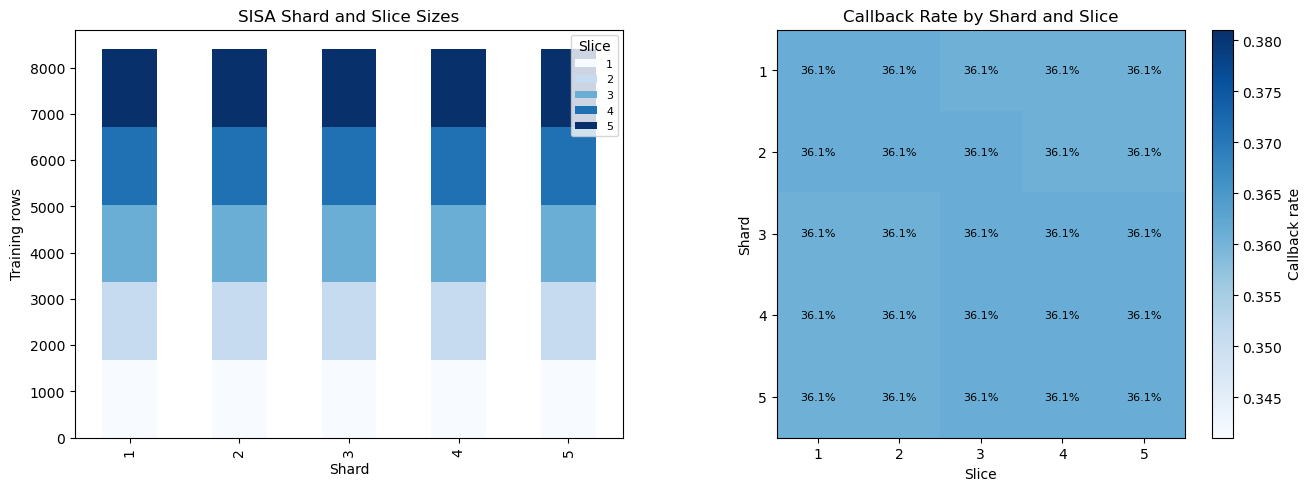

In [26]:
# Show both assignment size and callback balance without changing the assignment.
composition_figure, composition_axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
pivot_rows = shard_slice_composition.pivot(index="shard", columns="slice", values="rows")
pivot_rows.plot(kind="bar", stacked=True, ax=composition_axes[0], colormap="Blues")
composition_axes[0].set(title="SISA Shard and Slice Sizes", xlabel="Shard", ylabel="Training rows")
composition_axes[0].legend(title="Slice", fontsize=8)
pivot_rates = shard_slice_composition.pivot(index="shard", columns="slice", values="callback_rate")
image = composition_axes[1].imshow(pivot_rates, cmap="Blues", vmin=target.loc[train_indices].mean()-0.02,
                                   vmax=target.loc[train_indices].mean()+0.02)
composition_axes[1].set(title="Callback Rate by Shard and Slice", xlabel="Slice", ylabel="Shard",
                        xticks=np.arange(5), xticklabels=SLICE_NUMBERS,
                        yticks=np.arange(5), yticklabels=SHARD_NUMBERS)
for row in range(5):
    for column in range(5):
        composition_axes[1].text(column, row, f"{pivot_rates.iloc[row, column]:.1%}",
                                 ha="center", va="center", fontsize=8)
composition_figure.colorbar(image, ax=composition_axes[1], label="Callback rate")
display(composition_figure)
plt.close(composition_figure)

## 5. SISA Deletion Processing

### 5.1 Request Planning

Each forget row is mapped to its pre-existing shard and slice. An affected shard restarts from the saved checkpoint immediately before its earliest affected slice; slice-one requests reinitialize the shard. Unaffected final shard models are reused unchanged.

In [27]:
# Locate each forget row's shard and earliest affected slice before replay.
# Request planning observes the frozen assignment but never changes it.
assignment_by_index = assignment.set_index("train_index")
request_plan_rows = []
request_plans = {}
for name in SCENARIO_NAMES:
    forget_assignment = assignment_by_index.loc[forget_indices[name]]
    earliest = forget_assignment.groupby("shard")["slice"].min().astype(int).to_dict()
    affected = sorted(earliest)
    unaffected = sorted(set(SHARD_NUMBERS) - set(affected))
    request_plans[name] = {"earliest": earliest, "affected": affected, "unaffected": unaffected}
    request_plan_rows.append({
        "scenario": name, "forget_rows": len(forget_indices[name]),
        "affected_shards": len(affected), "unaffected_shards": len(unaffected),
        "earliest_slices": json.dumps(earliest, sort_keys=True),
        "replayed_slices": sum(6 - earliest[shard] for shard in affected),
    })
request_plan = pd.DataFrame(request_plan_rows)
display(request_plan.style.hide(axis="index"))

scenario,forget_rows,affected_shards,unaffected_shards,earliest_slices,replayed_slices
s1_actor_withdrawal,415,5,0,"{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}",25
s2_submission_withdrawal,2137,5,0,"{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}",25
s3_agency_withdrawal,4224,5,0,"{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}",25
s4_project_closure,6289,5,0,"{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}",25
s5_retention_expiry,6298,5,0,"{""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1, ""5"": 1}",25


### 5.2 Replay Helper

In [28]:
# Resume before the earliest affected slice so all later influence is replayed.
# Restore optimizer state with model weights when a prior checkpoint exists.
def prepare_replay_start(shard: int, restart_slice: int):
    "Restore the state immediately before the earliest affected slice."
    reset_seed(shard_seed(shard))
    model = CastMeMLP(len(FEATURE_COLUMNS)).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=SISA_CONFIG["learning_rate"],
        weight_decay=SISA_CONFIG["weight_decay"],
    )
    # Slice-one deletion has no earlier checkpoint, so recreate the original initialization.
    if restart_slice == 1:
        return model, optimizer, original_sisa[shard]["initial_state_hash"], "reinitialization"
    checkpoint = original_sisa[shard]["checkpoints"][restart_slice - 1]
    model.load_state_dict(checkpoint["state_dict"])
    optimizer.load_state_dict(copy.deepcopy(checkpoint["optimizer_state_dict"]))
    return model, optimizer, checkpoint["state_hash"], f"checkpoint_after_slice_{restart_slice - 1}"

In [29]:
# Replay only one affected shard under the original cumulative protocol.
def replay_affected_shard(name: str, shard: int, earliest: int, validation_x, validation_y):
    "Replay one affected shard without any applicable forget record."
    forget_set = set(forget_indices[name].tolist())
    model, optimizer, source_hash, source_kind = prepare_replay_start(shard, earliest)
    history_rows, replayed_rows, exposures = [], 0, 0
    for slice_number in range(earliest, 6):
        eligible = assignment.loc[
            assignment["shard"].eq(shard) & assignment["slice"].le(slice_number),
            "train_index",
        ].to_numpy(dtype=np.int64)
        # Remove every scenario forget row from every cumulative replay stage.
        stage_rows = np.asarray([value for value in eligible if value not in forget_set], dtype=np.int64)
        assert forget_set.isdisjoint(stage_rows.tolist())
        started = time.perf_counter()
        train_bce = train_fixed_stage(model, optimizer, stage_rows, shard_seed(shard) + slice_number * 100)
        history_rows.append({
            "scenario": name, "shard": shard, "slice": slice_number,
            "rows_used": len(stage_rows), "epochs": SISA_CONFIG["epochs_per_slice"],
            "training_bce": train_bce,
            "validation_bce": average_bce(model, validation_x, validation_y),
            "runtime_seconds": time.perf_counter() - started,
        })
        replayed_rows += len(stage_rows)
        exposures += len(stage_rows) * SISA_CONFIG["epochs_per_slice"]
    record = {
        "shard": shard, "affected": True, "earliest_affected_slice": earliest,
        "replayed_slices": 6-earliest, "replayed_rows": replayed_rows,
        "training_row_exposures": exposures, "source_checkpoint_hash": source_hash,
        "source_checkpoint_kind": source_kind, "final_checkpoint_hash": state_dict_hash(model.state_dict()),
    }
    return model.eval(), record, history_rows

In [30]:
# Reuse an unaffected final shard instead of retraining it.
def reuse_unaffected_shard(shard: int):
    "Reload an unaffected final shard and preserve its exact state hash."
    original_final = original_sisa[shard]["checkpoints"][5]
    model = CastMeMLP(len(FEATURE_COLUMNS)).to(DEVICE)
    model.load_state_dict(original_final["state_dict"])
    # Unaffected shard hashes must remain unchanged after a deletion request.
    assert state_dict_hash(model.state_dict()) == original_final["state_hash"]
    record = {
        "shard": shard, "affected": False, "earliest_affected_slice": np.nan,
        "replayed_slices": 0, "replayed_rows": 0, "training_row_exposures": 0,
        "source_checkpoint_hash": original_final["state_hash"],
        "source_checkpoint_kind": "reused_final_checkpoint",
        "final_checkpoint_hash": original_final["state_hash"],
    }
    return model.eval(), record

In [31]:
# Combine updated affected shards with byte-equivalent unaffected shard states.
# Retained validation is monitoring-only during request replay.
def construct_scenario_ensemble(name: str) -> dict[str, object]:
    "Combine replayed affected shards with unchanged final shards."
    plan = request_plans[name]
    validation_x = torch.tensor(
        baseline_preprocessor.transform(scenario_data[name]["retain_validation_x"]).astype(np.float32)
    )
    validation_y = torch.tensor(scenario_data[name]["retain_validation_y"].to_numpy(), dtype=torch.float32)
    models, records, history_rows = {}, [], []
    started = time.perf_counter()
    for shard in SHARD_NUMBERS:
        if shard in plan["affected"]:
            model, record, shard_history = replay_affected_shard(
                name, shard, plan["earliest"][shard], validation_x, validation_y
            )
            history_rows.extend(shard_history)
        else:
            model, record = reuse_unaffected_shard(shard)
        models[shard] = model
        records.append(record)
    return {
        "models": models, "shards": pd.DataFrame(records),
        "history": pd.DataFrame(history_rows),
        "request_runtime_seconds": time.perf_counter()-started,
    }

### 5.3 Process Five Deletion Requests

In [32]:
# Process each request independently against the same Original SISA ensemble.
sisa_runs = {}
for name in SCENARIO_NAMES:
    sisa_runs[name] = construct_scenario_ensemble(name)
    print(
        f"{SCENARIOS[name]['display_name']}: "
        f"{int(sisa_runs[name]['shards']['affected'].sum())} affected shards; "
        f"{int(sisa_runs[name]['shards']['replayed_slices'].sum())} replayed slices."
    )

Actor withdrawal — 1%: 5 affected shards; 25 replayed slices.


Submission withdrawal — 5%: 5 affected shards; 25 replayed slices.


Agency withdrawal — 10%: 5 affected shards; 25 replayed slices.


Project closure — 15%: 5 affected shards; 25 replayed slices.


Retention expiry — 15%: 5 affected shards; 25 replayed slices.


In [33]:
# Separate unique replay scope, row exposure and request-time runtime.
replay_summary_rows = []
for name, run in sisa_runs.items():
    shard_table = run["shards"]
    plan = request_plans[name]
    assert len(run["models"]) == 5
    assert int(shard_table["affected"].sum()) == len(plan["affected"])
    for shard in plan["unaffected"]:
        row = shard_table.loc[shard_table["shard"].eq(shard)].iloc[0]
        assert row["final_checkpoint_hash"] == original_sisa[shard]["checkpoints"][5]["state_hash"]
    replay_summary_rows.append({
        "scenario": name, "forget_rows": len(forget_indices[name]),
        "affected_shards": len(plan["affected"]), "unaffected_shards": len(plan["unaffected"]),
        "replayed_slices": int(shard_table["replayed_slices"].sum()),
        "replayed_rows": int(shard_table["replayed_rows"].sum()),
        "training_row_exposures": int(shard_table["training_row_exposures"].sum()),
        "request_runtime_seconds": run["request_runtime_seconds"],
    })
replay_summary = pd.DataFrame(replay_summary_rows)
replay_shard_details = pd.concat(
    [run["shards"].assign(scenario=name) for name, run in sisa_runs.items()],
    ignore_index=True,
)
display(replay_summary.style.hide(axis="index").format({"request_runtime_seconds": "{:.2f}"}))

scenario,forget_rows,affected_shards,unaffected_shards,replayed_slices,replayed_rows,training_row_exposures,request_runtime_seconds
s1_actor_withdrawal,415,5,0,25,124797,249594,16.00
s2_submission_withdrawal,2137,5,0,25,119347,238694,15.83
s3_agency_withdrawal,4224,5,0,25,113167,226334,15.95
s4_project_closure,6289,5,0,25,107049,214098,14.76
s5_retention_expiry,6298,5,0,25,107193,214386,13.95


### 5.4 Replay Verification

Only affected shards are replayed, every replay stage excludes the complete scenario forget set, and unaffected final state hashes remain identical.

In [34]:
# Reconstruct every replay stage to verify that forget rows were absent.
# Confirm the observed lack of shard and later-slice localisation.
for name, run in sisa_runs.items():
    forgotten = set(forget_indices[name].tolist())
    for _, stage in run["history"].iterrows():
        eligible = assignment.loc[
            assignment["shard"].eq(stage["shard"])
            & assignment["slice"].le(stage["slice"]), "train_index"
        ]
        expected_rows = [value for value in eligible if value not in forgotten]
        assert len(expected_rows) == stage["rows_used"]
        assert forgotten.isdisjoint(expected_rows)
    assert run["history"]["training_bce"].map(np.isfinite).all()
    assert run["history"]["validation_bce"].map(np.isfinite).all()
assert replay_summary["affected_shards"].eq(5).all()
assert replay_summary["replayed_slices"].eq(25).all()
assert replay_summary["unaffected_shards"].eq(0).all()
print("Replay exclusions verified; every request affected all shards from slice one.")

Replay exclusions verified; every request affected all shards from slice one.


### 5.5 Method-Matched Clean SISA References

The cross-method reference remains Notebook 02's monolithic MLP for consistency across CastMe methods. A separate internal verification trains a clean retain-only SISA ensemble from the beginning using identical assignments, architecture, seeds, cumulative protocol and frozen preprocessor. The two comparisons remain distinct.

In [35]:
# Train a method-matched clean shard with forget rows absent from stage one.
# Match assignment, seeds, architecture and cumulative training exactly.
def train_clean_retain_only_shard(name: str, shard: int):
    "Train one method-matched shard with forget rows excluded from stage one."
    forget_set = set(forget_indices[name].tolist())
    reset_seed(shard_seed(shard))
    model = CastMeMLP(len(FEATURE_COLUMNS)).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=SISA_CONFIG["learning_rate"],
        weight_decay=SISA_CONFIG["weight_decay"],
    )
    history_rows = []
    for slice_number in SLICE_NUMBERS:
        eligible = assignment.loc[
            assignment["shard"].eq(shard) & assignment["slice"].le(slice_number), "train_index"
        ].to_numpy(dtype=np.int64)
        stage_rows = np.asarray([value for value in eligible if value not in forget_set], dtype=np.int64)
        assert forget_set.isdisjoint(stage_rows.tolist())
        train_bce = train_fixed_stage(model, optimizer, stage_rows, shard_seed(shard)+slice_number*100)
        history_rows.append({
            "scenario": name, "shard": shard, "slice": slice_number,
            "rows_used": len(stage_rows), "training_bce": train_bce,
            "contains_forget_rows": False,
        })
    return model.eval(), history_rows

In [36]:
# Build clean retain-only ensembles solely for internal replay verification.
method_matched_runs = {}
for name in SCENARIO_NAMES:
    models, history_rows = {}, []
    started = time.perf_counter()
    for shard in SHARD_NUMBERS:
        models[shard], shard_history = train_clean_retain_only_shard(name, shard)
        history_rows.extend(shard_history)
    method_matched_runs[name] = {
        "models": models, "history": pd.DataFrame(history_rows),
        "runtime_seconds": time.perf_counter()-started,
    }
    assert not method_matched_runs[name]["history"]["contains_forget_rows"].any()

In [37]:
# Exact equality checks deterministic replay against fresh retain-only training.
method_matched_verification_rows = []
for name in SCENARIO_NAMES:
    sample = scenario_data[name]["retain_test_x"]
    replayed = predict_ensemble(sisa_runs[name]["models"], sample)
    clean = predict_ensemble(method_matched_runs[name]["models"], sample)
    maximum_difference = float(np.max(np.abs(replayed-clean)))
    method_matched_verification_rows.append({
        "scenario": name, "maximum_retained_test_probability_difference": maximum_difference,
        "predictions_equal": np.allclose(replayed, clean, rtol=1e-7, atol=1e-8),
        "clean_reference_contains_forget_rows": False,
    })
method_matched_verification = pd.DataFrame(method_matched_verification_rows)
assert method_matched_verification["predictions_equal"].all()
display(method_matched_verification.style.hide(axis="index").format(precision=10))

scenario,maximum_retained_test_probability_difference,predictions_equal,clean_reference_contains_forget_rows
s1_actor_withdrawal,0.0000000000,True,False
s2_submission_withdrawal,0.0000000000,True,False
s3_agency_withdrawal,0.0000000000,True,False
s4_project_closure,0.0000000000,True,False
s5_retention_expiry,0.0000000000,True,False


## 6. Evaluation Datasets

The primary forget set contains deleted training records. The primary utility set contains scenario-specific retained test records. Supporting matched-test rows satisfy each scenario condition but were never deleted training records. SISA and full retraining always score identical rows.

In [38]:
# Report primary forget, retained utility and supporting matched-test row counts.
evaluation_set_summary = pd.DataFrame([{
    "scenario": name, "forget_training_rows": len(data["forget_y"]),
    "retained_test_rows": len(data["retain_test_y"]),
    "scenario_matched_test_rows": len(data["matched_test_y"]),
} for name, data in scenario_data.items()])
display(evaluation_set_summary.style.hide(axis="index"))

scenario,forget_training_rows,retained_test_rows,scenario_matched_test_rows
s1_actor_withdrawal,415,8920,80
s2_submission_withdrawal,2137,8590,410
s3_agency_withdrawal,4224,8079,921
s4_project_closure,6289,7616,1384
s5_retention_expiry,6298,7681,1319


## 7. Axis 1: Retained-Data Utility

Post-deletion SISA and the Monolithic full-retraining external reference are compared on identical retained-test rows. Balanced accuracy and F1 use the fixed threshold 0.32. The five metrics remain separate; no composite Utility score is created.

In [39]:
# Keep the monolithic external reference distinct from clean SISA verification.
# Evaluate both utility models on identical retained-test rows.
def load_reference_model(name: str) -> nn.Module:
    checkpoint = full_checkpoints[name]
    model = CastMeMLP(checkpoint["input_dim"])
    model.load_state_dict(checkpoint["state_dict"])
    return model.to(DEVICE).eval()


SCENARIO_DISPLAY = {name: SCENARIOS[name]["display_name"] for name in SCENARIO_NAMES}
MODEL_DISPLAY = {"post_deletion_sisa": "Post-deletion SISA", "full_retraining": "Monolithic full-retraining external reference"}
utility_rows, utility_probability_cache = [], {}
for name in SCENARIO_NAMES:
    data = scenario_data[name]
    reference_model = load_reference_model(name)
    probabilities = {
        "post_deletion_sisa": predict_ensemble(sisa_runs[name]["models"], data["retain_test_x"]),
        "full_retraining": predict_model(reference_model, data["retain_test_x"], full_preprocessors[name]),
    }
    utility_probability_cache[name] = probabilities
    for model_name, values in probabilities.items():
        utility_rows.append({
            "scenario": name, "model": model_name, "retained_test_rows": len(data["retain_test_y"]),
            "threshold": THRESHOLD, **classification_metrics(data["retain_test_y"], values),
        })
utility_metrics = pd.DataFrame(utility_rows)

In [40]:
# Present only the five approved utility metrics with human-readable labels.
primary_utility_metrics = utility_metrics[[
    "scenario", "model", "pr_auc", "balanced_accuracy", "bce", "f1", "auroc"
]].copy()
primary_utility_table = primary_utility_metrics.copy()
primary_utility_table["scenario"] = primary_utility_table["scenario"].map(SCENARIO_DISPLAY)
primary_utility_table["model"] = primary_utility_table["model"].map(MODEL_DISPLAY)
primary_utility_table.columns = [
    "Scenario", "Model", "PR-AUC", "Balanced Accuracy", "BCE", "F1", "AUROC"
]
display(primary_utility_table.style.hide(axis="index").format(precision=4))

Scenario,Model,PR-AUC,Balanced Accuracy,BCE,F1,AUROC
Actor withdrawal — 1%,Post-deletion SISA,0.6281,0.6967,0.5479,0.6346,0.7675
Actor withdrawal — 1%,Monolithic full-retraining external reference,0.6252,0.6980,0.5474,0.6339,0.7678
Submission withdrawal — 5%,Post-deletion SISA,0.6281,0.6972,0.5482,0.6339,0.7674
Submission withdrawal — 5%,Monolithic full-retraining external reference,0.6270,0.6988,0.5474,0.6344,0.7676
Agency withdrawal — 10%,Post-deletion SISA,0.6331,0.7024,0.5456,0.6415,0.7714
Agency withdrawal — 10%,Monolithic full-retraining external reference,0.6315,0.7026,0.5443,0.6416,0.7720
Project closure — 15%,Post-deletion SISA,0.6387,0.7005,0.5490,0.6452,0.7702
Project closure — 15%,Monolithic full-retraining external reference,0.6380,0.7021,0.5471,0.6457,0.7714
Retention expiry — 15%,Post-deletion SISA,0.6328,0.7021,0.5444,0.6393,0.7718
Retention expiry — 15%,Monolithic full-retraining external reference,0.6318,0.7016,0.5433,0.6358,0.7727


### 7.1 Utility Gaps to Full Retraining

In [41]:
# Express every utility difference as SISA minus monolithic full retraining.
HEADLINE_UTILITY_METRICS = ["pr_auc", "balanced_accuracy", "bce", "f1", "auroc"]
utility_gap_rows = []
for name in SCENARIO_NAMES:
    rows = utility_metrics.query("scenario == @name").set_index("model")
    for model_name in rows.index:
        utility_gap_rows.append({
            "scenario": name, "model": model_name,
            **{f"{metric}_gap_to_full_retraining": rows.loc[model_name, metric] - rows.loc["full_retraining", metric]
               for metric in HEADLINE_UTILITY_METRICS},
        })
utility_gaps = pd.DataFrame(utility_gap_rows)
display(utility_gaps.style.hide(axis="index").format(precision=4))

scenario,model,pr_auc_gap_to_full_retraining,balanced_accuracy_gap_to_full_retraining,bce_gap_to_full_retraining,f1_gap_to_full_retraining,auroc_gap_to_full_retraining
s1_actor_withdrawal,post_deletion_sisa,0.0029,-0.0013,0.0005,0.0008,-0.0003
s1_actor_withdrawal,full_retraining,0.0000,0.0000,0.0000,0.0000,0.0000
s2_submission_withdrawal,post_deletion_sisa,0.0011,-0.0016,0.0009,-0.0004,-0.0003
s2_submission_withdrawal,full_retraining,0.0000,0.0000,0.0000,0.0000,0.0000
s3_agency_withdrawal,post_deletion_sisa,0.0015,-0.0001,0.0013,-0.0001,-0.0006
s3_agency_withdrawal,full_retraining,0.0000,0.0000,0.0000,0.0000,0.0000
s4_project_closure,post_deletion_sisa,0.0007,-0.0016,0.0018,-0.0005,-0.0012
s4_project_closure,full_retraining,0.0000,0.0000,0.0000,0.0000,0.0000
s5_retention_expiry,post_deletion_sisa,0.0010,0.0005,0.0011,0.0035,-0.0009
s5_retention_expiry,full_retraining,0.0000,0.0000,0.0000,0.0000,0.0000


### 7.2 Paired Actor–Role Cluster Bootstrap Confidence Intervals

The same 1,000 sampled actor–role clusters index both models. Intervals describe retained-test observation uncertainty, not training-seed variability.

In [42]:
# Sample actor–role clusters once and apply each draw to both models.
# Preserve repeated audition rounds within their sampled cluster.
def paired_cluster_bootstrap(labels, clusters, sisa_probabilities, reference_probabilities, seed):
    rng, y_values = np.random.default_rng(seed), labels.to_numpy()
    unique_clusters = np.unique(clusters)
    positions_by_cluster = {key: np.flatnonzero(clusters == key) for key in unique_clusters}
    rows = []
    for _ in range(BOOTSTRAP_RESAMPLES):
        sampled = rng.choice(unique_clusters, size=len(unique_clusters), replace=True)
        positions = np.concatenate([positions_by_cluster[key] for key in sampled])
        if np.unique(y_values[positions]).size < 2:
            continue
        sisa_metrics = classification_metrics(pd.Series(y_values[positions]), sisa_probabilities[positions])
        full_metrics = classification_metrics(pd.Series(y_values[positions]), reference_probabilities[positions])
        rows.append({metric: sisa_metrics[metric] - full_metrics[metric]
                     for metric in HEADLINE_UTILITY_METRICS})
    return pd.DataFrame(rows), len(unique_clusters)

In [43]:
# Use deterministic paired resamples for all five headline metrics.
utility_ci_rows = []
for position, name in enumerate(SCENARIO_NAMES):
    bootstrap, cluster_count = paired_cluster_bootstrap(
        scenario_data[name]["retain_test_y"], scenario_data[name]["retain_test_clusters"],
        utility_probability_cache[name]["post_deletion_sisa"],
        utility_probability_cache[name]["full_retraining"], BOOTSTRAP_SEED + position,
    )
    assert len(bootstrap) == BOOTSTRAP_RESAMPLES
    for metric in HEADLINE_UTILITY_METRICS:
        point = utility_gaps.query(
            "scenario == @name and model == 'post_deletion_sisa'"
        )[f"{metric}_gap_to_full_retraining"].iloc[0]
        utility_ci_rows.append({
            "scenario": name, "metric": metric, "point_difference": point,
            "ci_lower": bootstrap[metric].quantile(0.025),
            "ci_upper": bootstrap[metric].quantile(0.975),
            "valid_resamples": len(bootstrap), "unique_cluster_count": cluster_count,
            "bootstrap_method": "paired_actor_role_cluster_bootstrap",
        })
utility_difference_cis = pd.DataFrame(utility_ci_rows)
display(utility_difference_cis.style.hide(axis="index").format(precision=4))

scenario,metric,point_difference,ci_lower,ci_upper,valid_resamples,unique_cluster_count,bootstrap_method
s1_actor_withdrawal,pr_auc,0.0029,-0.0000,0.0057,1000,7841,paired_actor_role_cluster_bootstrap
s1_actor_withdrawal,balanced_accuracy,-0.0013,-0.0052,0.0025,1000,7841,paired_actor_role_cluster_bootstrap
s1_actor_withdrawal,bce,0.0005,-0.0008,0.0019,1000,7841,paired_actor_role_cluster_bootstrap
s1_actor_withdrawal,f1,0.0008,-0.0034,0.0048,1000,7841,paired_actor_role_cluster_bootstrap
s1_actor_withdrawal,auroc,-0.0003,-0.0016,0.0009,1000,7841,paired_actor_role_cluster_bootstrap
s2_submission_withdrawal,pr_auc,0.0011,-0.0014,0.0039,1000,7591,paired_actor_role_cluster_bootstrap
s2_submission_withdrawal,balanced_accuracy,-0.0016,-0.0058,0.0025,1000,7591,paired_actor_role_cluster_bootstrap
s2_submission_withdrawal,bce,0.0009,-0.0003,0.0022,1000,7591,paired_actor_role_cluster_bootstrap
s2_submission_withdrawal,f1,-0.0004,-0.0050,0.0038,1000,7591,paired_actor_role_cluster_bootstrap
s2_submission_withdrawal,auroc,-0.0003,-0.0015,0.0009,1000,7591,paired_actor_role_cluster_bootstrap


## 8. Axis 2: CastMe Forget Quality

For record *i*, `p_correct = y*p + (1-y)*(1-p)` and the Classifier Truth Ratio is `(1-p_correct)/p_correct`. It equals `exp(per-record BCE)-1`. Higher KS p-values mean less evidence of a distributional difference; lower KS statistics indicate smaller separation. A high p-value does not prove equal distributions or complete forgetting.

P-values depend on set size and are not directly comparable rankings. The KS test also ignores the natural pairing of identical records. This is a classifier-specific, TOFU-inspired adaptation rather than the original generative Truth Ratio.

In [44]:
# Clip correct-label probabilities before log and odds calculations.
# Verify the classifier Truth Ratio equals exp(per-record BCE) minus one.
TRUTH_RATIO_EPSILON = 1e-7
TRUTH_RATIO_DEFINITION = "(1 - p_correct) / p_correct, where p_correct = y*p + (1-y)*(1-p)"


def per_example_loss(labels: pd.Series, probabilities: np.ndarray) -> np.ndarray:
    y_values = labels.to_numpy(dtype=float)
    probabilities = np.clip(probabilities.astype(float), TRUTH_RATIO_EPSILON, 1-TRUTH_RATIO_EPSILON)
    return -(y_values*np.log(probabilities) + (1-y_values)*np.log(1-probabilities))


def true_label_confidence(labels: pd.Series, probabilities: np.ndarray) -> np.ndarray:
    y_values = labels.to_numpy(dtype=float)
    return y_values*probabilities + (1-y_values)*(1-probabilities)


def classifier_truth_ratio(labels: pd.Series, probabilities: np.ndarray) -> np.ndarray:
    correct = np.clip(true_label_confidence(labels, probabilities), TRUTH_RATIO_EPSILON, 1-TRUTH_RATIO_EPSILON)
    ratios = (1-correct)/correct
    assert np.isfinite(ratios).all() and (ratios >= 0).all()
    return ratios

In [45]:
# Calculate KS and paired diagnostics on the same forget records.
# Keep KS p-values and statistics bounded before saving results.
def comparison_diagnostics(labels, values, reference, comparison_type, scenario_name):
    "Calculate one complete, explicitly labelled Forget Quality comparison."
    losses = per_example_loss(labels, values)
    reference_losses = per_example_loss(labels, reference)
    confidence = true_label_confidence(labels, values)
    reference_confidence = true_label_confidence(labels, reference)
    ratios = classifier_truth_ratio(labels, values)
    reference_ratios = classifier_truth_ratio(labels, reference)
    assert np.allclose(ratios, np.expm1(losses), rtol=1e-6, atol=1e-7)
    ks_result = ks_2samp(ratios, reference_ratios, method="auto")
    return {
        "scenario": SCENARIO_DISPLAY[scenario_name], "comparison_type": comparison_type,
        "reference_model": ("Monolithic full-retraining external reference"
            if comparison_type.startswith("cross_method") else "Clean retain-only SISA method-matched reference"),
        "forget_set_row_count": len(labels), "ks_p_value": ks_result.pvalue,
        "ks_statistic": ks_result.statistic,
        "probability_mae": np.abs(values-reference).mean(),
        "prediction_agreement": ((values>=THRESHOLD)==(reference>=THRESHOLD)).mean(),
        "absolute_bce_difference": abs(losses.mean()-reference_losses.mean()),
        "absolute_true_label_confidence_difference": abs(confidence.mean()-reference_confidence.mean()),
        "truth_ratio_definition": TRUTH_RATIO_DEFINITION, "seed": MASTER_SEED,
        "fixed_threshold": THRESHOLD,
    }

In [46]:
# Do not merge architectural similarity with deterministic replay correctness.
# Score both comparisons on identical scenario forget rows.
cross_method_rows, method_matched_rows = [], []
original_forget_cache, post_forget_cache = {}, {}
for name in SCENARIO_NAMES:
    data = scenario_data[name]
    post_values = predict_ensemble(sisa_runs[name]["models"], data["forget_x"])
    clean_values = predict_ensemble(method_matched_runs[name]["models"], data["forget_x"])
    reference_model = load_reference_model(name)
    monolithic_values = predict_model(reference_model, data["forget_x"], full_preprocessors[name])
    original_forget_cache[name] = predict_ensemble(original_models, data["forget_x"])
    post_forget_cache[name] = post_values
    # Keep architecture-changing and method-matched references in separate result rows.
    cross_method_rows.append(comparison_diagnostics(
        data["forget_y"], post_values, monolithic_values,
        "cross_method_vs_monolithic_full_retraining", name,
    ))
    method_matched_rows.append(comparison_diagnostics(
        data["forget_y"], post_values, clean_values,
        "method_matched_vs_clean_retain_only_sisa", name,
    ))
cross_method_forget_quality = pd.DataFrame(cross_method_rows)
method_matched_forget_quality = pd.DataFrame(method_matched_rows)
forget_quality_comparisons = pd.concat(
    [cross_method_forget_quality, method_matched_forget_quality], ignore_index=True
)

In [47]:
# Display very small p-values in scientific notation rather than as zero.
for frame in [cross_method_forget_quality, method_matched_forget_quality]:
    assert frame["ks_p_value"].between(0, 1).all()
    assert frame["ks_statistic"].between(0, 1).all()
display(Markdown("**Cross-method comparison: post-deletion SISA vs Monolithic full-retraining external reference**"))
display(cross_method_forget_quality[[
    "scenario", "forget_set_row_count", "ks_p_value", "ks_statistic",
    "probability_mae", "prediction_agreement", "absolute_bce_difference",
    "absolute_true_label_confidence_difference",
]].style.hide(axis="index").format({
    "ks_p_value": "{:.3e}", "ks_statistic": "{:.4f}",
    "probability_mae": "{:.4f}", "prediction_agreement": "{:.2%}",
    "absolute_bce_difference": "{:.4f}",
    "absolute_true_label_confidence_difference": "{:.4f}",
}))
display(Markdown("**Method-matched verification: post-deletion SISA vs clean retain-only SISA**"))
display(method_matched_forget_quality[[
    "scenario", "forget_set_row_count", "ks_p_value", "ks_statistic",
    "probability_mae", "prediction_agreement", "absolute_bce_difference",
    "absolute_true_label_confidence_difference",
]].style.hide(axis="index").format({
    "ks_p_value": "{:.3e}", "ks_statistic": "{:.4f}",
    "probability_mae": "{:.4f}", "prediction_agreement": "{:.2%}",
    "absolute_bce_difference": "{:.4f}",
    "absolute_true_label_confidence_difference": "{:.4f}",
}))

**Cross-method comparison: post-deletion SISA vs Monolithic full-retraining external reference**

scenario,forget_set_row_count,ks_p_value,ks_statistic,probability_mae,prediction_agreement,absolute_bce_difference,absolute_true_label_confidence_difference
Actor withdrawal — 1%,415,1.696e-01,0.0771,0.0168,97.11%,0.0020,0.0080
Submission withdrawal — 5%,2137,7.961e-02,0.0388,0.0206,96.12%,0.0019,0.0050
Agency withdrawal — 10%,4224,6.614e-02,0.0284,0.0238,94.98%,0.0004,0.0028
Project closure — 15%,6289,3.403e-06,0.0460,0.0247,96.10%,0.0014,0.0057
Retention expiry — 15%,6298,4.700e-07,0.0492,0.0252,95.63%,0.0011,0.0062


**Method-matched verification: post-deletion SISA vs clean retain-only SISA**

scenario,forget_set_row_count,ks_p_value,ks_statistic,probability_mae,prediction_agreement,absolute_bce_difference,absolute_true_label_confidence_difference
Actor withdrawal — 1%,415,1.000e+00,0.0000,0.0000,100.00%,0.0000,0.0000
Submission withdrawal — 5%,2137,1.000e+00,0.0000,0.0000,100.00%,0.0000,0.0000
Agency withdrawal — 10%,4224,1.000e+00,0.0000,0.0000,100.00%,0.0000,0.0000
Project closure — 15%,6289,1.000e+00,0.0000,0.0000,100.00%,0.0000,0.0000
Retention expiry — 15%,6298,1.000e+00,0.0000,0.0000,100.00%,0.0000,0.0000


### 8.1 Supplementary Forget-Set Diagnostics

These diagnostics use the Original SISA ensemble for before-and-after context. They remain separate from the headline Forget Quality score.

In [48]:
# Keep probability, agreement and confidence diagnostics outside the headline score.
supplementary_rows = []
for name in SCENARIO_NAMES:
    data = scenario_data[name]
    reference_model = load_reference_model(name)
    reference = predict_model(reference_model, data["forget_x"], full_preprocessors[name])
    original_distance = np.abs(original_forget_cache[name]-reference).mean()
    post_distance = np.abs(post_forget_cache[name]-reference).mean()
    cross = cross_method_forget_quality.loc[
        cross_method_forget_quality["scenario"].eq(SCENARIO_DISPLAY[name])
    ].iloc[0]
    supplementary_rows.append({
        "scenario": name, "forget_rows": len(data["forget_y"]),
        "mean_absolute_probability_difference_from_external_reference": post_distance,
        "prediction_agreement_with_external_reference": cross["prediction_agreement"],
        "absolute_bce_difference_from_external_reference": cross["absolute_bce_difference"],
        "absolute_true_label_confidence_difference_from_external_reference": cross["absolute_true_label_confidence_difference"],
        "original_sisa_probability_distance": original_distance,
        "original_sisa_to_external_gap_closed_percentage": (original_distance-post_distance)/original_distance,
    })
supplementary_forget_diagnostics = pd.DataFrame(supplementary_rows)
display(supplementary_forget_diagnostics.style.hide(axis="index").format(precision=4))

scenario,forget_rows,mean_absolute_probability_difference_from_external_reference,prediction_agreement_with_external_reference,absolute_bce_difference_from_external_reference,absolute_true_label_confidence_difference_from_external_reference,original_sisa_probability_distance,original_sisa_to_external_gap_closed_percentage
s1_actor_withdrawal,415,0.0168,0.9711,0.0020,0.0080,0.0168,-0.0013
s2_submission_withdrawal,2137,0.0206,0.9612,0.0019,0.0050,0.0219,0.0602
s3_agency_withdrawal,4224,0.0238,0.9498,0.0004,0.0028,0.0229,-0.0404
s4_project_closure,6289,0.0247,0.9610,0.0014,0.0057,0.0230,-0.0722
s5_retention_expiry,6298,0.0252,0.9563,0.0011,0.0062,0.0244,-0.0306


### 8.2 Supporting Scenario-Matched Behaviour

In [49]:
# Treat condition-matched held-out behaviour as supporting evidence only.
matched_rows = []
for name in SCENARIO_NAMES:
    data = scenario_data[name]
    reference_model = load_reference_model(name)
    probabilities = {
        "original_sisa": predict_ensemble(original_models, data["matched_test_x"]),
        "post_deletion_sisa": predict_ensemble(sisa_runs[name]["models"], data["matched_test_x"]),
        "full_retraining": predict_model(reference_model, data["matched_test_x"], full_preprocessors[name]),
    }
    reference = probabilities["full_retraining"]
    for model_name, values in probabilities.items():
        matched_rows.append({
            "scenario": name, "model": model_name, "matched_test_rows": len(data["matched_test_y"]),
            "mean_probability": values.mean(),
            "mean_absolute_probability_difference_from_full": np.abs(values-reference).mean(),
        })
matched_test_behaviour = pd.DataFrame(matched_rows)
display(matched_test_behaviour.style.hide(axis="index").format(precision=4))

scenario,model,matched_test_rows,mean_probability,mean_absolute_probability_difference_from_full
s1_actor_withdrawal,original_sisa,80,0.2041,0.0182
s1_actor_withdrawal,post_deletion_sisa,80,0.2031,0.0181
s1_actor_withdrawal,full_retraining,80,0.1912,0.0000
s2_submission_withdrawal,original_sisa,410,0.3442,0.0197
s2_submission_withdrawal,post_deletion_sisa,410,0.3375,0.0189
s2_submission_withdrawal,full_retraining,410,0.3359,0.0000
s3_agency_withdrawal,original_sisa,921,0.3355,0.0229
s3_agency_withdrawal,post_deletion_sisa,921,0.3340,0.0239
s3_agency_withdrawal,full_retraining,921,0.3357,0.0000
s4_project_closure,original_sisa,1384,0.3203,0.0230


## 9. Supporting Results

### 9.1 Original SISA Training History

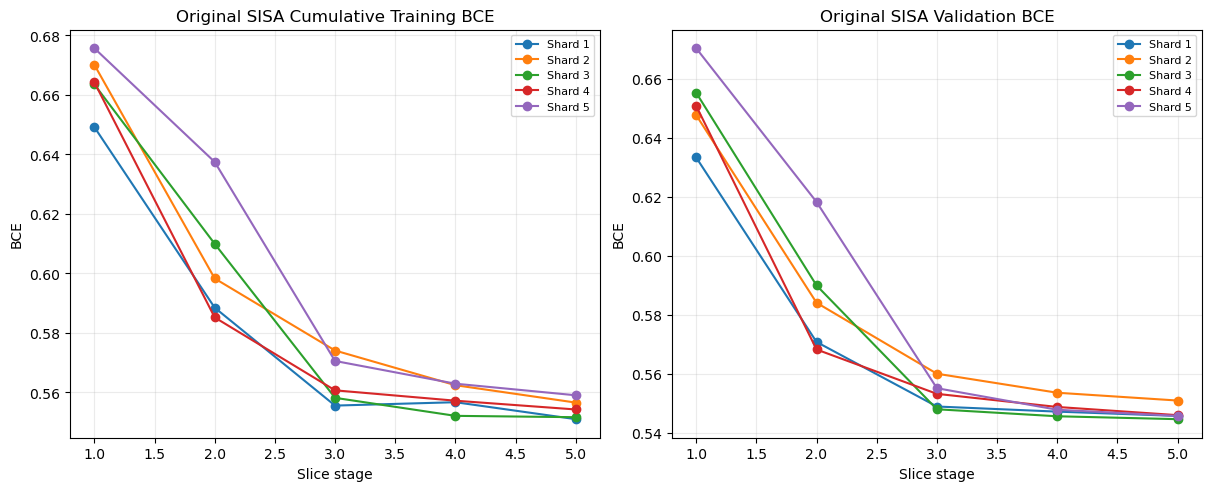

In [50]:
# Plot original shard histories without using them for model selection.
history_figure, history_axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
for shard in SHARD_NUMBERS:
    rows = original_training_history.query("shard == @shard")
    history_axes[0].plot(rows["slice"], rows["training_bce"], marker="o", label=f"Shard {shard}")
    history_axes[1].plot(rows["slice"], rows["validation_bce"], marker="o", label=f"Shard {shard}")
history_axes[0].set(title="Original SISA Cumulative Training BCE", xlabel="Slice stage", ylabel="BCE")
history_axes[1].set(title="Original SISA Validation BCE", xlabel="Slice stage", ylabel="BCE")
for axis in history_axes:
    axis.grid(alpha=0.25); axis.legend(fontsize=8)
display(history_figure)
plt.close(history_figure)

### 9.2 Affected Shards and Replayed Slices

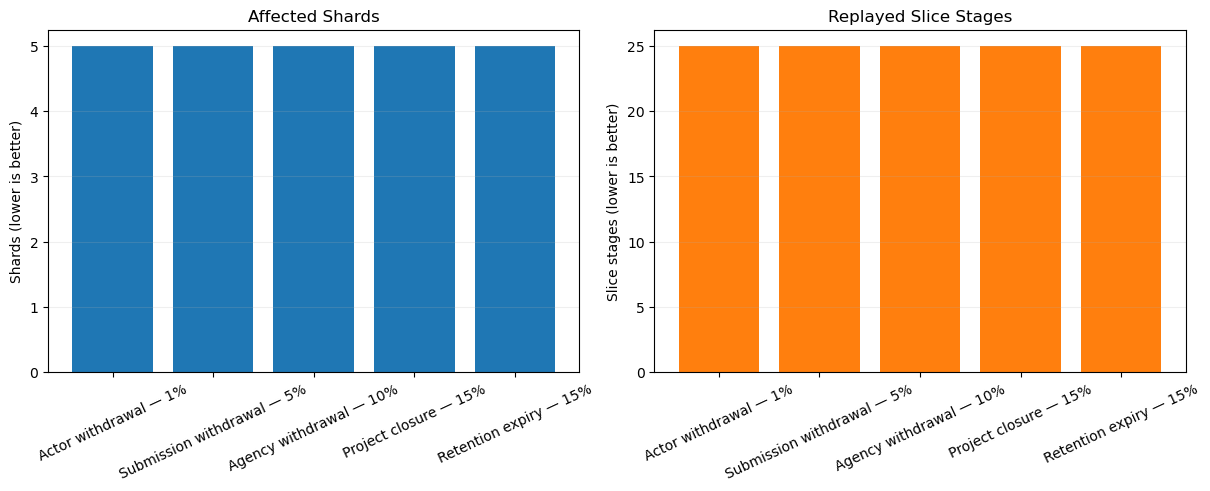

In [51]:
# Visualise how random assignment spreads each request across replay stages.
replay_figure, replay_axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
labels = [SCENARIO_DISPLAY[name] for name in replay_summary["scenario"]]
positions = np.arange(len(labels))
replay_axes[0].bar(positions, replay_summary["affected_shards"], color="#1f77b4")
replay_axes[1].bar(positions, replay_summary["replayed_slices"], color="#ff7f0e")
for axis, title, ylabel in [
    (replay_axes[0], "Affected Shards", "Shards (lower is better)"),
    (replay_axes[1], "Replayed Slice Stages", "Slice stages (lower is better)"),
]:
    axis.set(title=title, ylabel=ylabel, xticks=positions, xticklabels=labels)
    axis.tick_params(axis="x", rotation=25); axis.grid(axis="y", alpha=0.2)
display(replay_figure)
plt.close(replay_figure)

### 9.3 CastMe Forget Quality Plot

The panels use different labelled scales. P-values span 0–1, while the KS-statistic scale expands to keep small differences visible.

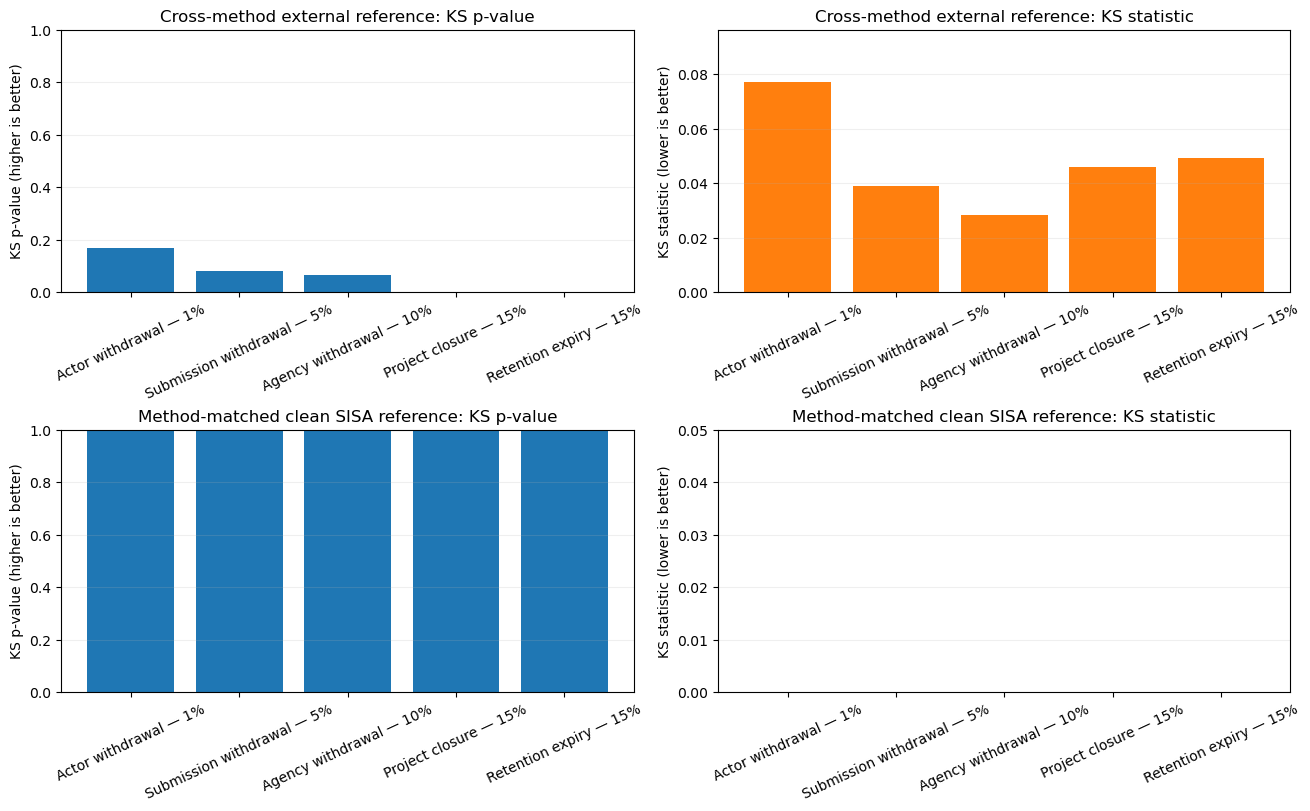

In [52]:
# Plot external and method-matched KS results on separately labelled scales.
quality_figure, quality_axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
positions = np.arange(len(SCENARIO_NAMES))
labels = [SCENARIO_DISPLAY[name] for name in SCENARIO_NAMES]
for row, (frame, title) in enumerate([
    (cross_method_forget_quality, "Cross-method external reference"),
    (method_matched_forget_quality, "Method-matched clean SISA reference"),
]):
    quality_axes[row, 0].bar(positions, frame["ks_p_value"], color="#1f77b4")
    quality_axes[row, 0].set(title=f"{title}: KS p-value", ylabel="KS p-value (higher is better)", ylim=(0, 1))
    upper = min(1.0, max(0.05, frame["ks_statistic"].max()*1.25))
    quality_axes[row, 1].bar(positions, frame["ks_statistic"], color="#ff7f0e")
    quality_axes[row, 1].set(title=f"{title}: KS statistic", ylabel="KS statistic (lower is better)", ylim=(0, upper))
    for axis in quality_axes[row]:
        axis.set(xticks=positions, xticklabels=labels)
        axis.tick_params(axis="x", rotation=25)
        axis.grid(axis="y", alpha=0.2)
display(quality_figure)
plt.close(quality_figure)

## 10. Computational Evaluation

SISA has an upfront ensemble-training and checkpoint-storage cost plus a separate request-time replay cost. Request-time speed-up excludes the upfront cost; total cost includes it. Benefits depend on how many shards and how early their affected slices occur.

In [53]:
# Exclude upfront training from request-time speed-up, then report total cost separately.
# Keep evaluation-only clean-reference runtime outside operational SISA cost.
runtime_rows = []
for name in SCENARIO_NAMES:
    request_runtime = sisa_runs[name]["request_runtime_seconds"]
    full_runtime = float(full_training_summary.loc[name, "runtime_seconds"])
    summary = replay_summary.set_index("scenario").loc[name]
    runtime_rows.append({
        "scenario": name, "initial_sisa_training_seconds": ORIGINAL_SISA_TRAINING_SECONDS,
        "affected_shards": int(summary["affected_shards"]),
        "replayed_slices": int(summary["replayed_slices"]),
        "replayed_rows": int(summary["replayed_rows"]),
        "sisa_request_runtime_seconds": request_runtime,
        "full_retraining_runtime_seconds": full_runtime,
        "request_time_saved_seconds": full_runtime-request_runtime,
        "request_time_speed_up_full_over_sisa": full_runtime/request_runtime,
        "total_sisa_cost_seconds": ORIGINAL_SISA_TRAINING_SECONDS+request_runtime,
        "total_cost_ratio_full_over_sisa": full_runtime/(ORIGINAL_SISA_TRAINING_SECONDS+request_runtime),
        "method_matched_reference_runtime_seconds": method_matched_runs[name]["runtime_seconds"],
        "sisa_device": str(DEVICE), "full_retraining_device": full_training_summary.loc[name, "device"],
    })
runtime_comparison = pd.DataFrame(runtime_rows)
display(runtime_comparison.style.hide(axis="index").format(precision=2))
# Runtime and storage remain separate because SISA pays both compute and checkpoint overhead.
print(
    f"Request-time speed-up range: {runtime_comparison['request_time_speed_up_full_over_sisa'].min():.2f}× to "
    f"{runtime_comparison['request_time_speed_up_full_over_sisa'].max():.2f}×."
)

scenario,initial_sisa_training_seconds,affected_shards,replayed_slices,replayed_rows,sisa_request_runtime_seconds,full_retraining_runtime_seconds,request_time_saved_seconds,request_time_speed_up_full_over_sisa,total_sisa_cost_seconds,total_cost_ratio_full_over_sisa,method_matched_reference_runtime_seconds,sisa_device,full_retraining_device
s1_actor_withdrawal,16.67,5,25,124797,16.00,45.93,29.94,2.87,32.67,1.41,15.71,mps,mps
s2_submission_withdrawal,16.67,5,25,119347,15.83,51.71,35.88,3.27,32.51,1.59,15.08,mps,mps
s3_agency_withdrawal,16.67,5,25,113167,15.95,50.00,34.05,3.13,32.63,1.53,14.51,mps,mps
s4_project_closure,16.67,5,25,107049,14.76,61.14,46.38,4.14,31.44,1.94,13.42,mps,mps
s5_retention_expiry,16.67,5,25,107193,13.95,51.33,37.38,3.68,30.62,1.68,13.71,mps,mps


Request-time speed-up range: 2.87× to 4.14×.


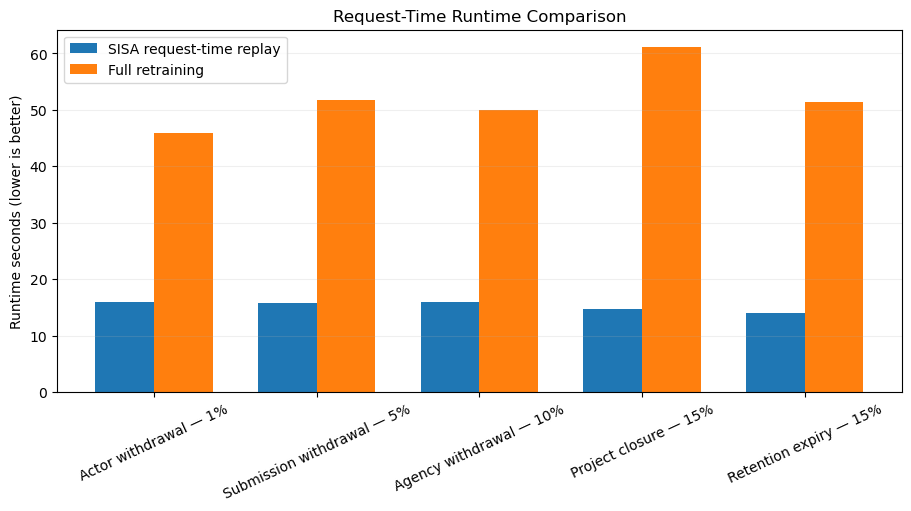

In [54]:
# Compare request replay with monolithic retraining on the recorded devices.
runtime_figure, runtime_axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
width = 0.36
positions = np.arange(len(runtime_comparison))
runtime_axis.bar(positions-width/2, runtime_comparison["sisa_request_runtime_seconds"], width,
                 label="SISA request-time replay", color="#1f77b4")
runtime_axis.bar(positions+width/2, runtime_comparison["full_retraining_runtime_seconds"], width,
                 label="Full retraining", color="#ff7f0e")
runtime_axis.set(title="Request-Time Runtime Comparison", ylabel="Runtime seconds (lower is better)",
                 xticks=positions, xticklabels=[SCENARIO_DISPLAY[name] for name in SCENARIO_NAMES])
runtime_axis.tick_params(axis="x", rotation=25)
runtime_axis.grid(axis="y", alpha=0.2); runtime_axis.legend()
display(runtime_figure)
plt.close(runtime_figure)

## 11. Save Outputs

Saving is centralised after training and evaluation. Original slice checkpoints retain model and optimizer state; scenario ensembles store five final shard models.

In [55]:
# Centralise assignment and operational checkpoint saving after evaluation.
# Operational storage covers 25 slice checkpoints and five original final models.
ASSIGNMENT_PATH = OUTPUT_DIRS["assignments"] / "shard_slice_assignments.csv"
assignment.to_csv(ASSIGNMENT_PATH, index=False)
ASSIGNMENT_FILE_HASH = sha256(ASSIGNMENT_PATH)

original_checkpoint_paths, original_final_paths = {}, {}
for shard in SHARD_NUMBERS:
    shard_directory = ORIGINAL_MODEL_ROOT / f"shard_{shard}"
    shard_directory.mkdir(parents=True, exist_ok=True)
    original_checkpoint_paths[shard] = {}
    for slice_number in SLICE_NUMBERS:
        path = shard_directory / f"slice_{slice_number}.pt"
        payload = {
            **original_sisa[shard]["checkpoints"][slice_number],
            "method": "sisa", "stage": "original", "shard": shard, "slice": slice_number,
            "seed": shard_seed(shard), "assignment_logical_hash": ASSIGNMENT_LOGICAL_HASH,
            "configuration": SISA_CONFIG, "input_dim": len(FEATURE_COLUMNS),
            "architecture": ARCHITECTURE, "feature_order": FEATURE_COLUMNS,
            "frozen_preprocessor_path": str(BASELINE_PREPROCESSOR_PATH.relative_to(CODE_ROOT)),
            "frozen_preprocessor_hash": sha256(BASELINE_PREPROCESSOR_PATH), "threshold": THRESHOLD,
        }
        torch.save(payload, path)
        original_checkpoint_paths[shard][slice_number] = path
    final_path = shard_directory / "final_model.pt"
    torch.save(payload, final_path)
    original_final_paths[shard] = final_path

In [56]:
# Save one five-shard post-deletion ensemble for each approved request.
post_deletion_paths = {}
for name, run in sisa_runs.items():
    scenario_directory = POST_DELETION_MODEL_ROOT / name
    scenario_directory.mkdir(parents=True, exist_ok=True)
    post_deletion_paths[name] = {}
    shard_records = run["shards"].set_index("shard")
    for shard in SHARD_NUMBERS:
        state = {key: value.detach().cpu().clone() for key, value in run["models"][shard].state_dict().items()}
        path = scenario_directory / f"shard_{shard}_model.pt"
        payload = {
            "state_dict": state, "state_hash": state_dict_hash(state), "method": "sisa",
            "stage": "post_deletion", "scenario": name, "shard": shard,
            "affected": bool(shard_records.loc[shard, "affected"]),
            "earliest_affected_slice": None if pd.isna(shard_records.loc[shard, "earliest_affected_slice"])
            else int(shard_records.loc[shard, "earliest_affected_slice"]),
            "source_checkpoint_hash": shard_records.loc[shard, "source_checkpoint_hash"],
            "forget_index_hash": index_hash(forget_indices[name]),
            "assignment_logical_hash": ASSIGNMENT_LOGICAL_HASH, "configuration": SISA_CONFIG,
            "input_dim": len(FEATURE_COLUMNS), "architecture": ARCHITECTURE,
            "feature_order": FEATURE_COLUMNS,
            "frozen_preprocessor_path": str(BASELINE_PREPROCESSOR_PATH.relative_to(CODE_ROOT)),
            "frozen_preprocessor_hash": sha256(BASELINE_PREPROCESSOR_PATH), "threshold": THRESHOLD,
        }
        torch.save(payload, path)
        post_deletion_paths[name][shard] = path

In [57]:
# Store evaluation-only clean references outside the operational model directory.
method_matched_paths = {}
for name, run in method_matched_runs.items():
    scenario_directory = METHOD_MATCHED_MODEL_ROOT / name
    scenario_directory.mkdir(parents=True, exist_ok=True)
    method_matched_paths[name] = {}
    for shard in SHARD_NUMBERS:
        state = {key: value.detach().cpu().clone() for key, value in run["models"][shard].state_dict().items()}
        path = scenario_directory / f"shard_{shard}_model.pt"
        torch.save({
            "state_dict": state, "state_hash": state_dict_hash(state),
            "method": "sisa", "reference_type": "clean_retain_only_method_matched_sisa",
            "scenario": name, "shard": shard, "seed": shard_seed(shard),
            "forget_index_hash": index_hash(forget_indices[name]),
            "assignment_logical_hash": ASSIGNMENT_LOGICAL_HASH,
            "configuration": SISA_CONFIG, "architecture": ARCHITECTURE,
            "input_dim": len(FEATURE_COLUMNS), "feature_order": FEATURE_COLUMNS,
            "threshold": THRESHOLD,
        }, path)
        method_matched_paths[name][shard] = path

In [58]:
# Save all executed tables and histories from one central artifact section.
TABLE_PATHS = {
    "shard_slice_composition": OUTPUT_DIRS["tables"] / "shard_slice_composition.csv",
    "original_training_history": OUTPUT_DIRS["histories"] / "original_sisa_training_history.csv",
    "original_sisa_utility": OUTPUT_DIRS["metrics"] / "original_sisa_utility.csv",
    "request_plan": OUTPUT_DIRS["tables"] / "request_plan.csv",
    "replay_summary": OUTPUT_DIRS["tables"] / "replay_summary.csv",
    "replay_shard_details": OUTPUT_DIRS["tables"] / "replay_shard_details.csv",
    "primary_utility_metrics": OUTPUT_DIRS["metrics"] / "primary_utility_metrics.csv",
    "utility_gaps": OUTPUT_DIRS["metrics"] / "utility_gaps.csv",
    "utility_difference_cis": OUTPUT_DIRS["metrics"] / "utility_difference_confidence_intervals.csv",
    "cross_method_forget_quality": OUTPUT_DIRS["metrics"] / "cross_method_forget_quality.csv",
    "forget_quality_compatibility": OUTPUT_DIRS["metrics"] / "forget_quality.csv",
    "method_matched_forget_quality": OUTPUT_DIRS["metrics"] / "method_matched_forget_quality.csv",
    "forget_quality_comparisons": OUTPUT_DIRS["metrics"] / "forget_quality_comparisons.csv",
    "forgetfulness_metrics_compatibility": OUTPUT_DIRS["metrics"] / "forgetfulness_metrics.csv",
    "supplementary_forget_diagnostics": OUTPUT_DIRS["metrics"] / "supplementary_forget_diagnostics.csv",
    "matched_test_behaviour": OUTPUT_DIRS["metrics"] / "scenario_matched_test_behaviour.csv",
    "runtime_comparison": OUTPUT_DIRS["tables"] / "runtime_comparison.csv",
    "method_matched_verification": OUTPUT_DIRS["tables"] / "method_matched_verification.csv",
}
TABLE_OBJECTS = {
    "shard_slice_composition": shard_slice_composition,
    "original_training_history": original_training_history,
    "original_sisa_utility": original_sisa_utility,
    "request_plan": request_plan, "replay_summary": replay_summary,
    "replay_shard_details": replay_shard_details,
    "primary_utility_metrics": primary_utility_metrics, "utility_gaps": utility_gaps,
    "utility_difference_cis": utility_difference_cis,
    "cross_method_forget_quality": cross_method_forget_quality,
    "forget_quality_compatibility": cross_method_forget_quality,
    "method_matched_forget_quality": method_matched_forget_quality,
    "forget_quality_comparisons": forget_quality_comparisons,
    "forgetfulness_metrics_compatibility": forget_quality_comparisons,
    "supplementary_forget_diagnostics": supplementary_forget_diagnostics,
    "matched_test_behaviour": matched_test_behaviour, "runtime_comparison": runtime_comparison,
    "method_matched_verification": method_matched_verification,
}
for name, frame in TABLE_OBJECTS.items():
    frame.to_csv(TABLE_PATHS[name], index=False)
for name, run in sisa_runs.items():
    run["history"].to_csv(OUTPUT_DIRS["histories"] / f"{name}_replay_history.csv", index=False)
for name, run in method_matched_runs.items():
    run["history"].to_csv(OUTPUT_DIRS["histories"] / f"{name}_clean_reference_history.csv", index=False)

In [59]:
# Export every established SISA figure at 300 DPI.
# Measure operational storage from original checkpoints and final shard models only.
FIGURE_PATHS = {
    "composition": OUTPUT_DIRS["figures"] / "shard_slice_composition.png",
    "original_history": OUTPUT_DIRS["figures"] / "original_sisa_training_history.png",
    "replay_scope": OUTPUT_DIRS["figures"] / "affected_shards_and_replayed_slices.png",
    "forget_quality": OUTPUT_DIRS["figures"] / "forget_quality_ks.png",
    "runtime": OUTPUT_DIRS["figures"] / "request_time_runtime_comparison.png",
}
for figure, path in [
    (composition_figure, FIGURE_PATHS["composition"]),
    (history_figure, FIGURE_PATHS["original_history"]),
    (replay_figure, FIGURE_PATHS["replay_scope"]),
    (quality_figure, FIGURE_PATHS["forget_quality"]),
    (runtime_figure, FIGURE_PATHS["runtime"]),
]:
    figure.savefig(path, dpi=300, bbox_inches="tight")

original_slice_checkpoint_files = [
    original_checkpoint_paths[shard][slice_number]
    for shard in SHARD_NUMBERS for slice_number in SLICE_NUMBERS
]
original_checkpoint_files = original_slice_checkpoint_files + list(original_final_paths.values())
INITIAL_CHECKPOINT_STORAGE_BYTES = sum(path.stat().st_size for path in original_checkpoint_files)
storage_summary = pd.DataFrame([{
    "storage_label": "Initial operational SISA storage",
    "original_slice_checkpoints": len(original_slice_checkpoint_files),
    "original_final_models": len(original_final_paths),
    "storage_bytes": INITIAL_CHECKPOINT_STORAGE_BYTES,
    "initial_operational_sisa_storage_megabytes": INITIAL_CHECKPOINT_STORAGE_BYTES / 1_000_000,
}])
STORAGE_PATH = OUTPUT_DIRS["tables"] / "checkpoint_storage.csv"
storage_summary.to_csv(STORAGE_PATH, index=False)
display(storage_summary.style.hide(axis="index").format({"initial_operational_sisa_storage_megabytes": "{:.2f}"}))

storage_label,original_slice_checkpoints,original_final_models,storage_bytes,initial_operational_sisa_storage_megabytes
Initial operational SISA storage,25,5,359460,0.36


In [60]:
# Record assignment and artifact provenance before reload verification.
RELOAD_VERIFICATION_PATH = OUTPUT_DIRS["tables"] / "reload_verification.csv"
assignment_manifest = {
    "method": "sisa", "created_before_deletion_processing": True,
    "master_seed": MASTER_SEED, "number_of_shards": 5, "number_of_slices": 5,
    "assignment_strategy": "nested deterministic stratified five-fold assignment",
    "assignment_path": str(ASSIGNMENT_PATH.relative_to(CODE_ROOT)),
    "assignment_file_hash": ASSIGNMENT_FILE_HASH,
    "assignment_logical_hash": ASSIGNMENT_LOGICAL_HASH,
    "training_row_count": len(assignment),
    "composition": json.loads(shard_slice_composition.to_json(orient="records")),
}
ASSIGNMENT_MANIFEST_PATH = OUTPUT_DIRS["configuration"] / "assignment_manifest.json"
ASSIGNMENT_MANIFEST_PATH.write_text(json.dumps(assignment_manifest, indent=2))

5999

In [61]:
# Describe both reference types and the frozen-preprocessor limitation explicitly.
artifact_manifest = {
    "method": "sisa", "method_name": "Sharded, Isolated, Sliced and Aggregated",
    "configuration": SISA_CONFIG, "assignment_manifest_path": str(ASSIGNMENT_MANIFEST_PATH.relative_to(CODE_ROOT)),
    "assignment_file_hash": ASSIGNMENT_FILE_HASH, "assignment_logical_hash": ASSIGNMENT_LOGICAL_HASH,
    "aggregation": "mean_predicted_probability", "threshold": THRESHOLD,
    "feature_order": FEATURE_COLUMNS, "architecture": ARCHITECTURE,
    "baseline_split_artifacts": baseline_manifest["split_artifacts"],
    "deletion_configuration": SCENARIOS,
    "preprocessing_limitation": "Frozen pre-deletion scaler may retain deleted-record influence; model-only SISA.",
    "reference_model_types": {
        "cross_method": "monolithic_full_retraining_external_reference",
        "method_matched": "clean_retain_only_sisa_ensemble",
    }, "frozen_preprocessor_path": str(BASELINE_PREPROCESSOR_PATH.relative_to(CODE_ROOT)),
    "frozen_preprocessor_hash": sha256(BASELINE_PREPROCESSOR_PATH),
    "raw_dataset_hash": RAW_DATASET_HASH, "cleaned_dataset_hash": CLEANED_DATASET_HASH,
    "original_sisa_training_seconds": ORIGINAL_SISA_TRAINING_SECONDS,
    "initial_checkpoint_storage_bytes": INITIAL_CHECKPOINT_STORAGE_BYTES,
    "initial_operational_sisa_storage_scope": "25 original slice checkpoints and five original final shard models; excludes post-deletion and evaluation-only references.",
    "upstream_artifact_hashes": UPSTREAM_HASHES_BEFORE,
    "original_checkpoint_paths": {str(shard): {str(slice_number): str(path.relative_to(CODE_ROOT))
        for slice_number, path in paths.items()} for shard, paths in original_checkpoint_paths.items()},
    "original_final_model_paths": {
        str(shard): str(path.relative_to(CODE_ROOT)) for shard, path in original_final_paths.items()
    },
    "method_matched_model_paths": {name: {str(shard): str(path.relative_to(CODE_ROOT))
        for shard, path in paths.items()} for name, paths in method_matched_paths.items()},
    "post_deletion_model_paths": {name: {str(shard): str(path.relative_to(CODE_ROOT))
        for shard, path in paths.items()} for name, paths in post_deletion_paths.items()},
    "table_paths": {name: str(path.relative_to(CODE_ROOT)) for name, path in TABLE_PATHS.items()},
    "storage_path": str(STORAGE_PATH.relative_to(CODE_ROOT)),
    "reload_verification_path": str(RELOAD_VERIFICATION_PATH.relative_to(CODE_ROOT)),
    "figure_paths": {name: str(path.relative_to(CODE_ROOT)) for name, path in FIGURE_PATHS.items()},
    "runtime_environment": {"python": platform.python_version(), "numpy": np.__version__,
        "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
        "pytorch": torch.__version__, "device": str(DEVICE)},
}
ARTIFACT_MANIFEST_PATH = OUTPUT_DIRS["configuration"] / "artifact_manifest.json"
ARTIFACT_MANIFEST_PATH.write_text(json.dumps(artifact_manifest, indent=2))
print(f"Saved SISA manifest: {ARTIFACT_MANIFEST_PATH.relative_to(CODE_ROOT)}")

Saved SISA manifest: results/CastMe/sisa/configuration/artifact_manifest.json


## 12. Reload and Verification

All assignments, tables, checkpoints and scenario ensembles are reloaded. Predictions and headline metrics must match, and upstream Notebook 01–04 artifacts must retain their original hashes.

In [62]:
# Reload every table and history rather than trusting in-memory objects.
def assert_saved_table(path: Path, expected: pd.DataFrame) -> None:
    saved = pd.read_csv(path)
    assert saved.columns.tolist() == expected.columns.tolist() and len(saved) == len(expected)
    for column in expected.columns:
        if pd.api.types.is_numeric_dtype(expected[column]):
            assert np.allclose(saved[column], expected[column], equal_nan=True)
        else:
            assert saved[column].fillna("").astype(str).tolist() == expected[column].fillna("").astype(str).tolist()


for name, frame in TABLE_OBJECTS.items():
    assert_saved_table(TABLE_PATHS[name], frame)
assert_saved_table(STORAGE_PATH, storage_summary)
reloaded_assignment = pd.read_csv(ASSIGNMENT_PATH)
assert reloaded_assignment.equals(assignment)
assert sha256(ASSIGNMENT_PATH) == ASSIGNMENT_FILE_HASH
assert json.loads(ASSIGNMENT_MANIFEST_PATH.read_text()) == assignment_manifest
for name, run in sisa_runs.items():
    assert_saved_table(OUTPUT_DIRS["histories"] / f"{name}_replay_history.csv", run["history"])
for name, run in method_matched_runs.items():
    assert_saved_table(OUTPUT_DIRS["histories"] / f"{name}_clean_reference_history.csv", run["history"])

In [63]:
# Reload all original slice checkpoints and prove optimizer state is portable.
for shard in SHARD_NUMBERS:
    for slice_number in SLICE_NUMBERS:
        saved = torch.load(original_checkpoint_paths[shard][slice_number], map_location="cpu", weights_only=False)
        expected = original_sisa[shard]["checkpoints"][slice_number]
        assert saved["state_hash"] == expected["state_hash"] == state_dict_hash(saved["state_dict"])
        # Prove saved optimizer state can be restored with the paired model checkpoint.
        portable = CastMeMLP(saved["input_dim"])
        portable.load_state_dict(saved["state_dict"])
        portable_optimizer = torch.optim.AdamW(portable.parameters(), lr=SISA_CONFIG["learning_rate"])
        portable_optimizer.load_state_dict(saved["optimizer_state_dict"])
        assert len(portable_optimizer.state) == len(saved["optimizer_state_dict"]["state"])
    saved_final = torch.load(original_final_paths[shard], map_location="cpu", weights_only=False)
    assert saved_final["state_hash"] == original_sisa[shard]["checkpoints"][5]["state_hash"]

In [64]:
# Rebuild both saved SISA ensembles and reproduce displayed predictions and metrics.
reload_rows = []
for name in SCENARIO_NAMES:
    reloaded_post, reloaded_clean = {}, {}
    for shard in SHARD_NUMBERS:
        post = torch.load(post_deletion_paths[name][shard], map_location="cpu", weights_only=False)
        clean = torch.load(method_matched_paths[name][shard], map_location="cpu", weights_only=False)
        for saved, destination in [(post, reloaded_post), (clean, reloaded_clean)]:
            model = CastMeMLP(saved["input_dim"])
            model.load_state_dict(saved["state_dict"])
            assert state_dict_hash(model.state_dict()) == saved["state_hash"]
            destination[shard] = model.to(DEVICE).eval()
    retained = predict_ensemble(reloaded_post, scenario_data[name]["retain_test_x"])
    assert np.allclose(retained, utility_probability_cache[name]["post_deletion_sisa"], rtol=1e-7, atol=1e-8)
    retained_metrics = classification_metrics(scenario_data[name]["retain_test_y"], retained)
    saved_utility = primary_utility_metrics.query("scenario == @name and model == 'post_deletion_sisa'").iloc[0]
    assert all(np.isclose(retained_metrics[metric], saved_utility[metric]) for metric in HEADLINE_UTILITY_METRICS)
    clean_forget = predict_ensemble(reloaded_clean, scenario_data[name]["forget_x"])
    post_forget = predict_ensemble(reloaded_post, scenario_data[name]["forget_x"])
    maximum_difference = float(np.max(np.abs(post_forget-clean_forget)))
    reference_model = load_reference_model(name)
    external_forget = predict_model(reference_model, scenario_data[name]["forget_x"], full_preprocessors[name])
    recomputed_cross = comparison_diagnostics(
        scenario_data[name]["forget_y"], post_forget, external_forget,
        "cross_method_vs_monolithic_full_retraining", name,
    )
    saved_cross = cross_method_forget_quality.loc[
        cross_method_forget_quality["scenario"].eq(SCENARIO_DISPLAY[name])
    ].iloc[0]
    comparison_metrics = ["ks_p_value", "ks_statistic", "probability_mae",
                          "prediction_agreement", "absolute_bce_difference",
                          "absolute_true_label_confidence_difference"]
    assert all(np.isclose(recomputed_cross[metric], saved_cross[metric]) for metric in comparison_metrics)
    reload_rows.append({
        "scenario": name, "post_deletion_models_reloaded": 5,
        "method_matched_models_reloaded": 5, "retained_predictions_match": True,
        "method_matched_maximum_probability_difference": maximum_difference,
        "method_matched_predictions_equal": np.allclose(post_forget, clean_forget, rtol=1e-7, atol=1e-8),
        "metrics_tables_reloaded": True, "displayed_metrics_reproduced": True,
    })
reload_verification = pd.DataFrame(reload_rows)
assert reload_verification["method_matched_predictions_equal"].all()
reload_verification.to_csv(RELOAD_VERIFICATION_PATH, index=False)
display(reload_verification.style.hide(axis="index").format(precision=10))

scenario,post_deletion_models_reloaded,method_matched_models_reloaded,retained_predictions_match,method_matched_maximum_probability_difference,method_matched_predictions_equal,metrics_tables_reloaded,displayed_metrics_reproduced
s1_actor_withdrawal,5,5,True,0.0000000000,True,True,True
s2_submission_withdrawal,5,5,True,0.0000000000,True,True,True
s3_agency_withdrawal,5,5,True,0.0000000000,True,True,True
s4_project_closure,5,5,True,0.0000000000,True,True,True
s5_retention_expiry,5,5,True,0.0000000000,True,True,True


In [65]:
# Finish with manifest, required-file and upstream-hash verification.
saved_artifact_manifest = json.loads(ARTIFACT_MANIFEST_PATH.read_text())
assert saved_artifact_manifest == artifact_manifest
current_upstream_hashes = {
    str(path.relative_to(CODE_ROOT)): sha256(path) for path in UPSTREAM_ARTIFACTS
}
assert current_upstream_hashes == UPSTREAM_HASHES_BEFORE
required_outputs = [
    ASSIGNMENT_PATH, ASSIGNMENT_MANIFEST_PATH, ARTIFACT_MANIFEST_PATH, STORAGE_PATH,
    *original_checkpoint_files,
    *[path for paths in post_deletion_paths.values() for path in paths.values()],
    *[path for paths in method_matched_paths.values() for path in paths.values()],
    RELOAD_VERIFICATION_PATH,
    *TABLE_PATHS.values(), *FIGURE_PATHS.values(),
]
assert all(path.is_file() for path in required_outputs)
print("All SISA artifacts reloaded; all upstream CastMe artifacts are unchanged.")

All SISA artifacts reloaded; all upstream CastMe artifacts are unchanged.


## 13. Final Discussion

### 13.1 Utility

In [66]:
# Generate polished utility labels and values directly from executed gap tables.
post_gaps = utility_gaps.query("model == 'post_deletion_sisa'")
UTILITY_DISPLAY_LABELS = {
    "pr_auc": "PR-AUC", "balanced_accuracy": "Balanced Accuracy",
    "bce": "BCE", "f1": "F1", "auroc": "AUROC",
}
maximum_gaps = {
    UTILITY_DISPLAY_LABELS[metric]: post_gaps[f"{metric}_gap_to_full_retraining"].abs().max()
    for metric in HEADLINE_UTILITY_METRICS
}
project_bce = utility_difference_cis.query(
    "scenario == 's4_project_closure' and metric == 'bce'"
).iloc[0]
project_excludes_zero = not (project_bce["ci_lower"] <= 0 <= project_bce["ci_upper"])
gap_bullets = "\n".join(
    f"- Maximum absolute {label} gap: {value:.4f}."
    for label, value in maximum_gaps.items()
)
display(Markdown(
    "Retained utility remains close to the Monolithic full-retraining external reference.\n\n"
    + gap_bullets
    + f"\n\nThe Project Closure BCE gap is {project_bce['point_difference']:+.4f}; its paired "
      "cluster-bootstrap confidence interval "
    + ("excludes zero, although the absolute difference remains small."
       if project_excludes_zero else "includes zero.")
))

Retained utility remains close to the Monolithic full-retraining external reference.

- Maximum absolute PR-AUC gap: 0.0029.
- Maximum absolute Balanced Accuracy gap: 0.0016.
- Maximum absolute BCE gap: 0.0018.
- Maximum absolute F1 gap: 0.0035.
- Maximum absolute AUROC gap: 0.0012.

The Project Closure BCE gap is +0.0018; its paired cluster-bootstrap confidence interval excludes zero, although the absolute difference remains small.

### 13.2 Forget Quality

In [67]:
# Interpret external similarity separately from exact method-matched replay.
cross_large = cross_method_forget_quality[cross_method_forget_quality["scenario"].isin([
    SCENARIO_DISPLAY["s4_project_closure"], SCENARIO_DISPLAY["s5_retention_expiry"]
])]
matched_equal = (
    method_matched_forget_quality["probability_mae"].le(1e-8).all()
    and method_matched_forget_quality["prediction_agreement"].eq(1).all()
)
display(Markdown(
    "The two 15% scenarios have cross-method KS p-values of "
    + " and ".join(f"{value:.3e}" for value in cross_large["ks_p_value"])
    + ". This shows separation from the monolithic reference, not proof that SISA failed to remove records, "
      "because the reference architecture differs. The method-matched clean retain-only SISA verification "
    + ("reproduces replayed SISA predictions within tolerance for every scenario; a method-matched "
        "KS p-value of 1 confirms deterministic replay here but is not regulatory proof." if matched_equal
       else "shows the numerical differences reported in the verification table.")
))

The two 15% scenarios have cross-method KS p-values of 3.403e-06 and 4.700e-07. This shows separation from the monolithic reference, not proof that SISA failed to remove records, because the reference architecture differs. The method-matched clean retain-only SISA verification reproduces replayed SISA predictions within tolerance for every scenario; a method-matched KS p-value of 1 confirms deterministic replay here but is not regulatory proof.

### 13.3 Efficiency and Localisation

In [68]:
# Generate all efficiency and localisation conclusions from current result tables.
request_min = runtime_comparison["request_time_speed_up_full_over_sisa"].min()
request_max = runtime_comparison["request_time_speed_up_full_over_sisa"].max()
total_min = runtime_comparison["total_cost_ratio_full_over_sisa"].min()
total_max = runtime_comparison["total_cost_ratio_full_over_sisa"].max()
all_faster = runtime_comparison["request_time_speed_up_full_over_sisa"].gt(1).all()
all_total_faster = runtime_comparison["total_cost_ratio_full_over_sisa"].gt(1).all()
localisation_failed = (
    replay_summary["affected_shards"].eq(5).all()
    and replay_summary["replayed_slices"].eq(25).all()
)
display(Markdown(
    f"Initial SISA training took {ORIGINAL_SISA_TRAINING_SECONDS:.2f} seconds. "
    f"Initial operational SISA storage was "
    f"{storage_summary['initial_operational_sisa_storage_megabytes'].iloc[0]:.2f} MB for the 25 original "
    "slice checkpoints and five original final shard models; post-deletion and evaluation-only "
    "reference models are excluded. "
    f"Request-time replay ranged from {runtime_comparison['sisa_request_runtime_seconds'].min():.2f} to "
    f"{runtime_comparison['sisa_request_runtime_seconds'].max():.2f} seconds, versus "
    f"{runtime_comparison['full_retraining_runtime_seconds'].min():.2f} to "
    f"{runtime_comparison['full_retraining_runtime_seconds'].max():.2f} seconds for full retraining. "
    f"Request-time speed-up was {request_min:.2f}×–{request_max:.2f}× and total-cost speed-up was "
    f"{total_min:.2f}×–{total_max:.2f}×. "
    + ("All five requests were faster at request time. " if all_faster else "Not every request was faster. ")
    + ("All five were also faster when the one-time initial training cost was included. "
       if all_total_faster else "Not every request remained faster after including initial training. ")
    + ("Every request affected all five shards from slice 1 and replayed all 25 stages; no unaffected final "
       "model or later-slice checkpoint was reused. Random row-level assignment therefore provided no shard "
       "localisation for CastMe's multi-row entity and cohort requests." if localisation_failed else "")
))

Initial SISA training took 16.67 seconds. Initial operational SISA storage was 0.36 MB for the 25 original slice checkpoints and five original final shard models; post-deletion and evaluation-only reference models are excluded. Request-time replay ranged from 13.95 to 16.00 seconds, versus 45.93 to 61.14 seconds for full retraining. Request-time speed-up was 2.87×–4.14× and total-cost speed-up was 1.41×–1.94×. All five requests were faster at request time. All five were also faster when the one-time initial training cost was included. Every request affected all five shards from slice 1 and replayed all 25 stages; no unaffected final model or later-slice checkpoint was reused. Random row-level assignment therefore provided no shard localisation for CastMe's multi-row entity and cohort requests.

### 13.4 Overall Trade-off

Generic row-level sharding is poorly aligned with CastMe's entity-level and cohort-level deletion requests. Entity-aware or deletion-aware sharding is future work and was not introduced after observing these requests. SISA may still become more valuable across repeated requests or with a suitable pre-deletion assignment strategy. Timing comparisons are illustrative and device-specific because the five-model cumulative SISA protocol differs from monolithic full retraining.

### 13.5 Limitations

- This is model-only SISA unlearning. The frozen pre-deletion scaler may retain deleted-record influence, so this is not complete pipeline-level erasure.
- The monolithic external reference and five-model SISA ensemble differ architecturally; low cross-method KS p-values cannot isolate deletion correctness.
- The method-matched clean SISA ensemble is the appropriate internal replay-correctness check, but behavioural equality is not regulatory proof.
- Results use one deterministic seed and configuration, not statistical inference across training seeds.
- KS p-values depend on sample size and ignore the natural pairing of predictions on identical rows.
- CastMe is synthetic, so findings may not transfer to operational casting data.